In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [3]:
df["Diagnosis"].value_counts()

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [4]:
df.shape

(782, 58)

In [5]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [6]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


appendicitis       463
no appendicitis    317
NaN                  2
Name: Diagnosis, dtype: int64

In [7]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [8]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [9]:
# correlation of different columns with each other
df.corr()

C:\Users\shadj\AppData\Local\Temp\ipykernel_26896\3540467011.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Age,BMI,Height,Weight,Length_of_Stay,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
Age,1.000000,0.480260,0.865212,0.766366,-0.103958,-0.088758,-0.181370,-0.127890,-0.030214,-0.290765,-0.248400,-0.177806,-0.450627,0.043015,0.256888,-0.011832,-0.261943,-0.130322,0.046207
BMI,0.480260,1.000000,0.462740,0.859202,-0.045762,-0.124772,-0.121359,-0.100005,0.040996,-0.151558,-0.122949,-0.183794,-0.217881,0.073769,0.175787,0.024529,-0.035245,-0.068655,0.043407
Height,0.865212,0.462740,1.000000,0.829438,-0.108980,-0.064345,-0.134157,-0.107983,-0.006397,-0.232372,-0.201797,-0.129100,-0.346772,0.078383,0.375145,-0.021228,-0.274992,-0.128182,0.002838
Weight,0.766366,0.859202,0.829438,1.000000,-0.066928,-0.099791,-0.146741,-0.121757,0.037628,-0.210826,-0.179033,-0.184130,-0.284693,0.089732,0.239662,0.003105,-0.172860,-0.092634,0.023028
Length_of_Stay,-0.103958,-0.045762,-0.108980,-0.066928,1.000000,0.385103,0.310115,0.227738,0.301530,0.226218,0.300919,0.233578,0.129662,-0.083149,-0.073525,0.084017,0.099924,0.524018,-0.118864
Diagnosis,-0.088758,-0.124772,-0.064345,-0.099791,0.385103,1.000000,0.419104,0.350888,0.629298,0.155629,0.361929,0.354624,0.538303,-0.026141,0.001865,0.057883,0.008935,0.284090,-0.241541
Alvarado_Score,-0.181370,-0.121359,-0.134157,-0.146741,0.310115,0.419104,1.000000,0.832473,0.337497,0.376022,0.639642,0.701133,0.699436,-0.006242,-0.052610,0.059918,0.068806,0.332292,-0.059370
Paedriatic_Appendicitis_Score,-0.127890,-0.100005,-0.107983,-0.121757,0.227738,0.350888,0.832473,1.000000,0.264968,0.299691,0.486760,0.554610,0.508287,-0.005896,-0.056656,0.020818,0.033673,0.266233,0.026625
Appendix_Diameter,-0.030214,0.040996,-0.006397,0.037628,0.301530,0.629298,0.337497,0.264968,1.000000,0.086271,0.333982,0.340236,0.373796,-0.063712,-0.004960,0.065832,0.039110,0.268492,-0.092364
Body_Temperature,-0.290765,-0.151558,-0.232372,-0.210826,0.226218,0.155629,0.376022,0.299691,0.086271,1.000000,0.273795,0.316383,0.152790,-0.038630,-0.071117,-0.010618,0.012231,0.318427,-0.231202


In [10]:
#  correlation of our output column with other columns
df.corr()['Diagnosis']

C:\Users\shadj\AppData\Local\Temp\ipykernel_26896\3928385209.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Diagnosis']


Age                             -0.088758
BMI                             -0.124772
Height                          -0.064345
Weight                          -0.099791
Length_of_Stay                   0.385103
Diagnosis                        1.000000
Alvarado_Score                   0.419104
Paedriatic_Appendicitis_Score    0.350888
Appendix_Diameter                0.629298
Body_Temperature                 0.155629
WBC_Count                        0.361929
Neutrophil_Percentage            0.354624
Segmented_Neutrophils            0.538303
RBC_Count                       -0.026141
Hemoglobin                       0.001865
RDW                              0.057883
Thrombocyte_Count                0.008935
CRP                              0.284090
US_Number                       -0.241541
Name: Diagnosis, dtype: float64

In [11]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [12]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [13]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [14]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [15]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [16]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [17]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

<h2>Selecting only those rows which have no nan values : </h2>

In [19]:
df2 = df.dropna().copy()

In [20]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,7.1,no,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,7.0,no,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,3.7,no,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,8.0,no,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,9.0,yes,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,7.0,yes,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,12.0,no,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,5.0,no,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,10.0,no,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [21]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness',
       'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object')

In [22]:
df2["WBC_in_Urine"].value_counts()

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [23]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [24]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [26]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [27]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [28]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [30]:
df2["Lower_Right_Abd_Pain"].value_counts()

yes    228
no      10
Name: Lower_Right_Abd_Pain, dtype: int64

In [31]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

1    228
0     10
Name: Lower_Right_Abd_Pain, dtype: int64

In [32]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

no     149
yes     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [33]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

0    149
1     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [34]:
df2["Coughing_Pain"].value_counts(dropna = False)

no     163
yes     75
Name: Coughing_Pain, dtype: int64

In [35]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

0    163
1     75
Name: Coughing_Pain, dtype: int64

In [36]:
df2["Nausea"].value_counts(dropna = False)

yes    132
no     106
Name: Nausea, dtype: int64

In [37]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

1    132
0    106
Name: Nausea, dtype: int64

In [38]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

yes    121
no     117
Name: Loss_of_Appetite, dtype: int64

In [39]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

1    121
0    117
Name: Loss_of_Appetite, dtype: int64

In [40]:
df2["Neutrophilia"].value_counts(dropna = False)

no     138
yes    100
Name: Neutrophilia, dtype: int64

In [41]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

0    138
1    100
Name: Neutrophilia, dtype: int64

In [42]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

no     148
+++     47
+       29
++      14
Name: Ketones_in_Urine, dtype: int64

In [43]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

0.0    148
3.0     47
1.0     29
2.0     14
Name: Ketones_in_Urine, dtype: int64

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [45]:
df2["RBC_in_Urine"].value_counts(dropna = False)

no     190
+       37
+++      7
++       4
Name: RBC_in_Urine, dtype: int64

In [46]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

0.0    190
1.0     37
3.0      7
2.0      4
Name: RBC_in_Urine, dtype: int64

In [47]:
df2["WBC_in_Urine"].value_counts(dropna= False)

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [48]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

0.0    206
1.0     22
2.0      7
3.0      3
Name: WBC_in_Urine, dtype: int64

In [49]:
df2["Dysuria"].value_counts(dropna= False)

no     227
yes     11
Name: Dysuria, dtype: int64

In [50]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

0    227
1     11
Name: Dysuria, dtype: int64

In [51]:
df2["Stool"].value_counts()
#will do one hot encoding here

normal          174
diarrhea         37
constipation     27
Name: Stool, dtype: int64

In [52]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

1.0    174
2.0     37
0.0     27
Name: Stool, dtype: int64

In [53]:
df2["Peritonitis"].value_counts()

no             189
local           43
generalized      6
Name: Peritonitis, dtype: int64

In [54]:
enc = OrdinalEncoder(categories=[['no','local','generalized']])
enc.fit([['no'], ['local'], ['generalized']])                                 
df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
df2["Peritonitis"].value_counts(dropna = False)

0.0    189
1.0     43
2.0      6
Name: Peritonitis, dtype: int64

In [55]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.1618742249964222

In [56]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis_binary"] = (df2["Peritonitis"]!=0).astype(int)

In [57]:
#dropping the Peritonitis Columns
df2.drop(["Peritonitis"],axis=1, inplace =True)

In [58]:
df2["Diagnosis"].corr(df2["Peritonitis_binary"])

0.19028246913072036

In [59]:
df2["Psoas_Sign"].value_counts()

no     160
yes     78
Name: Psoas_Sign, dtype: int64

In [60]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [61]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

no     226
yes     12
Name: Ipsilateral_Rebound_Tenderness, dtype: int64

In [62]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [63]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [64]:
df2.corr()["Diagnosis"]

C:\Users\shadj\AppData\Local\Temp\ipykernel_26896\3919710716.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]


Age                                -0.015028
BMI                                -0.014656
Sex                                 0.056833
Height                             -0.020931
Weight                             -0.019917
Diagnosis                           1.000000
Alvarado_Score                      0.396722
Paedriatic_Appendicitis_Score       0.330840
Appendix_Diameter                   0.657866
Migratory_Pain                      0.189311
Lower_Right_Abd_Pain                0.070571
Contralateral_Rebound_Tenderness    0.115277
Coughing_Pain                       0.086377
Nausea                              0.212755
Loss_of_Appetite                    0.091894
Body_Temperature                    0.083812
WBC_Count                           0.301403
Neutrophil_Percentage               0.247917
Neutrophilia                        0.180261
RBC_Count                          -0.074309
Hemoglobin                         -0.055650
RDW                                 0.061406
Thrombocyt

C:\Users\shadj\AppData\Local\Temp\ipykernel_26896\231157439.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<AxesSubplot: >

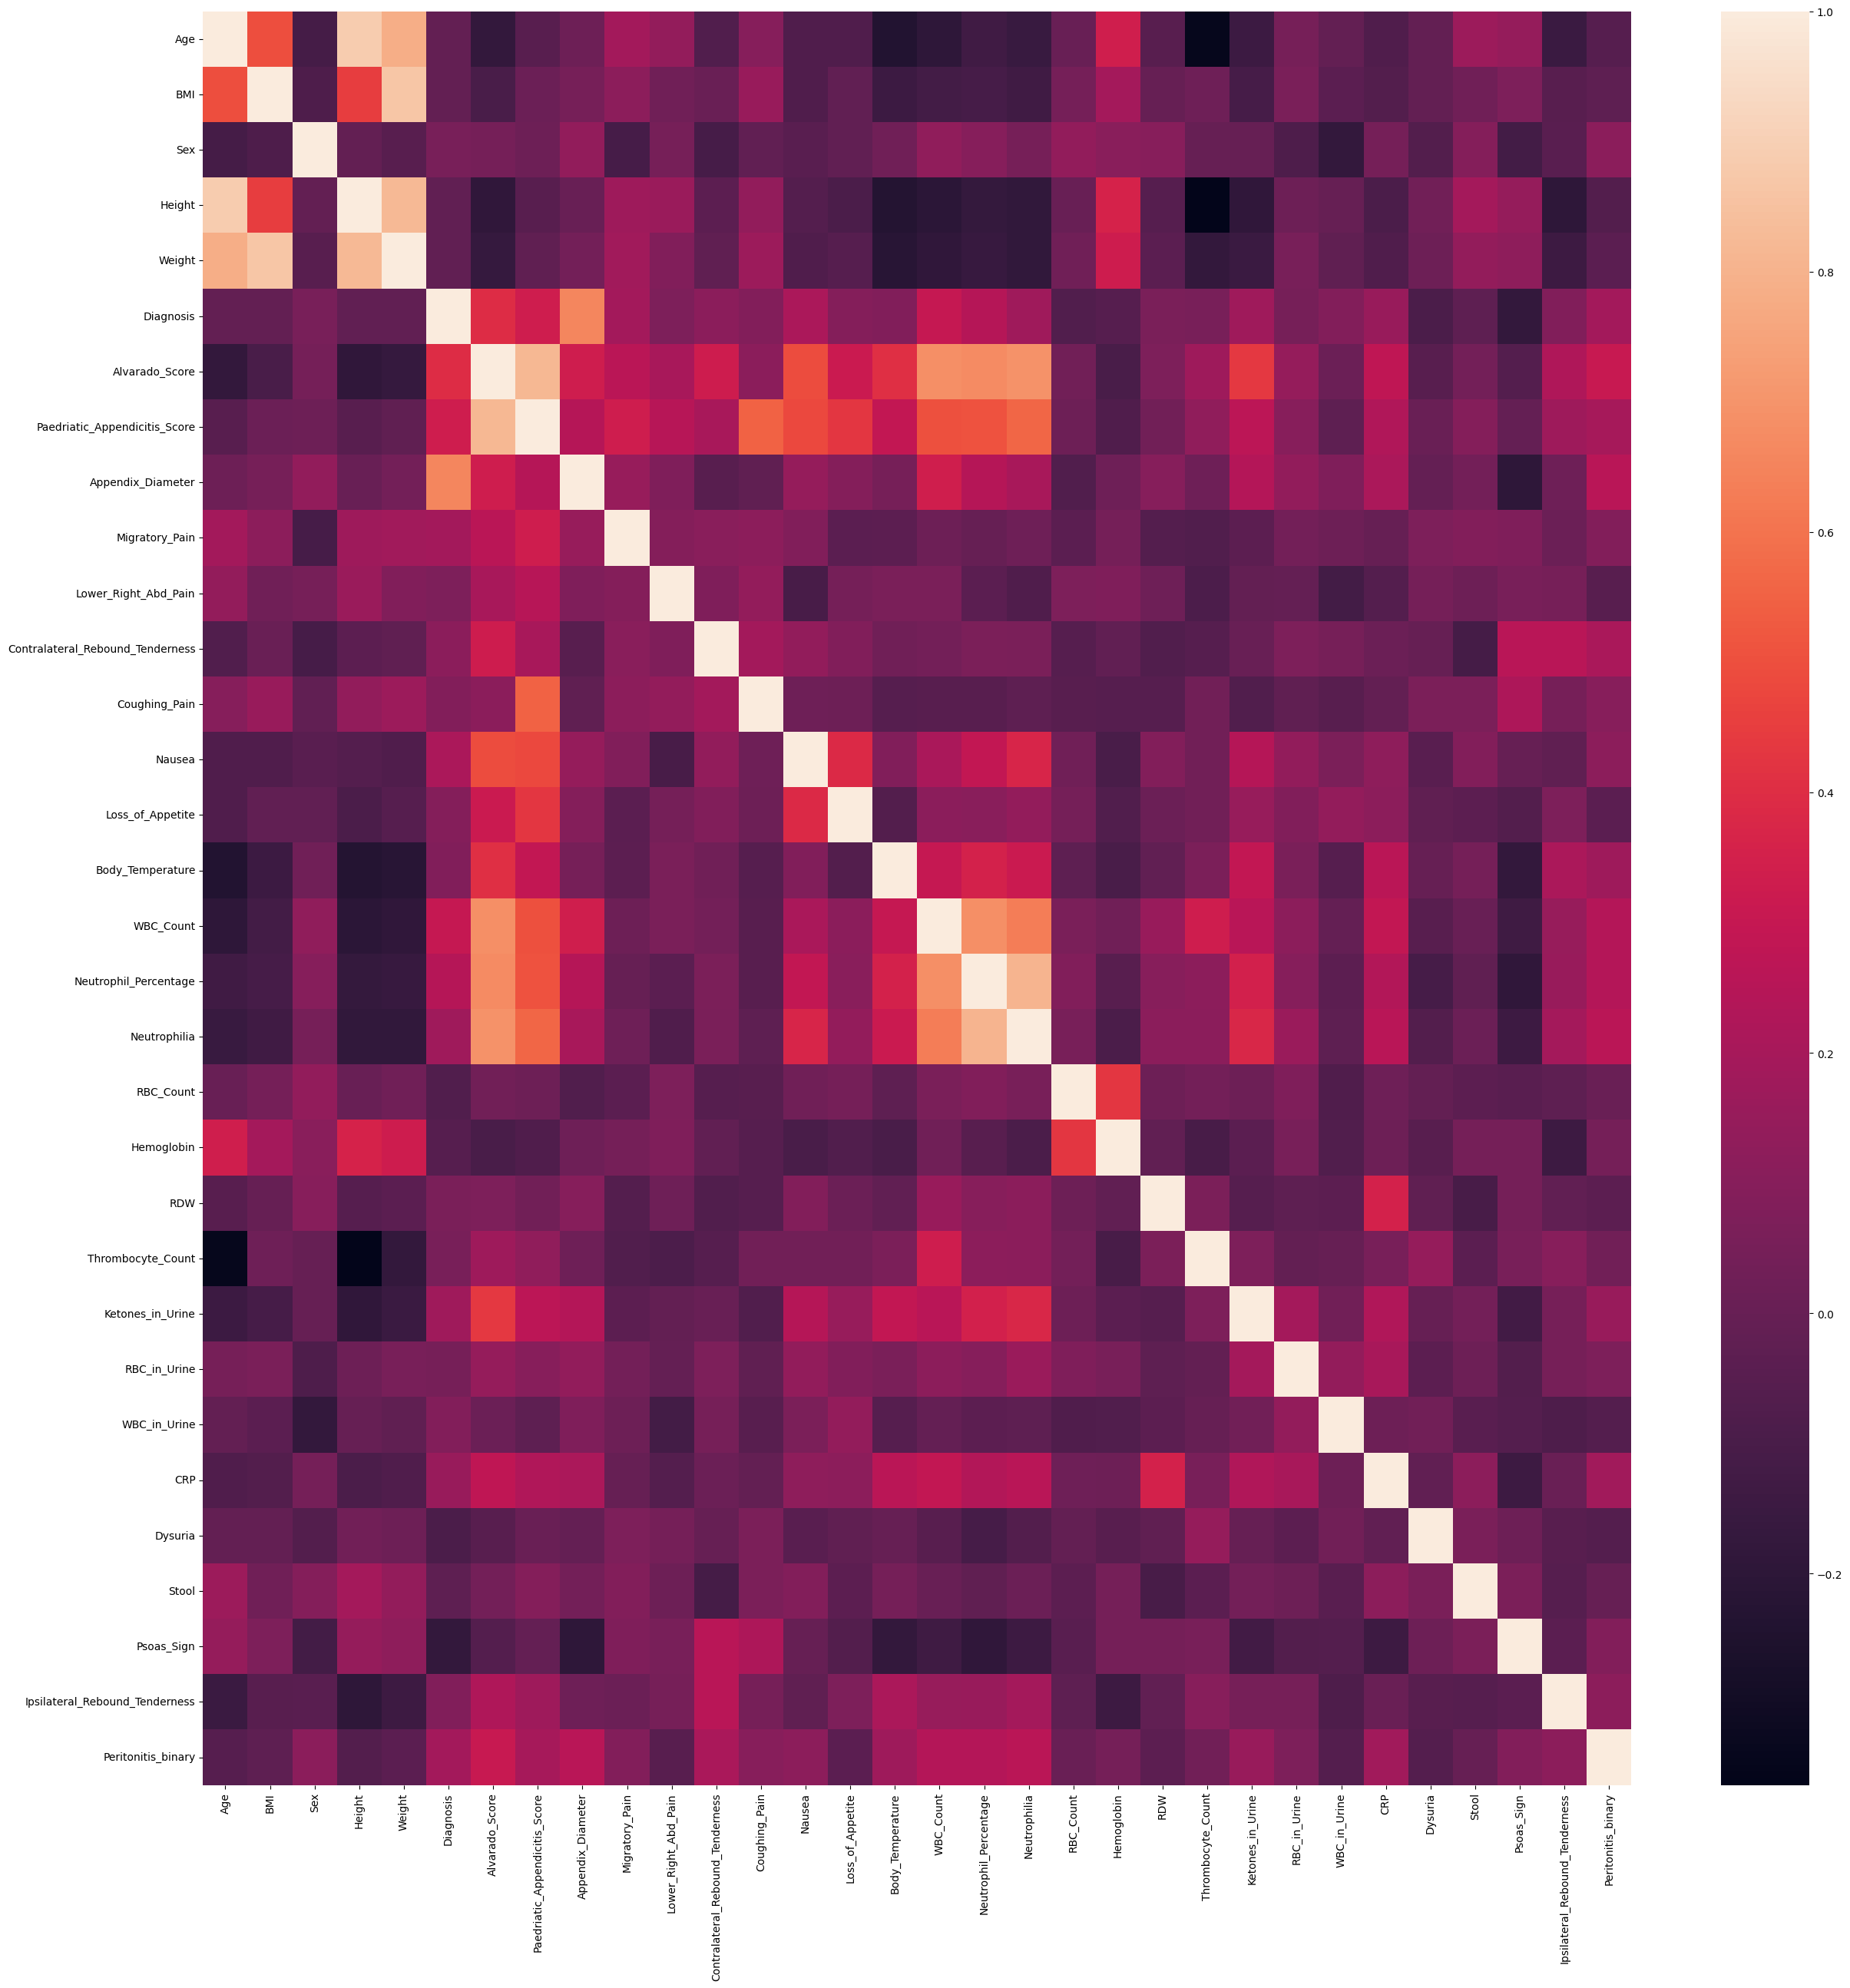

In [65]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [66]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [67]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [68]:
# dsafsf

In [69]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 32)

# APPLYING VARIANCE THRESHOLD FOR FEATURE SELECTION

In [70]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape


mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

Index(['Age', 'BMI', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'CRP'],
      dtype='object')

In [71]:
col = selected_cols
col =list(col)
col.append("Diagnosis")
df = df.loc[:,col]

In [72]:
col

['Age',
 'BMI',
 'Height',
 'Weight',
 'Alvarado_Score',
 'Paedriatic_Appendicitis_Score',
 'Appendix_Diameter',
 'Body_Temperature',
 'WBC_Count',
 'Neutrophil_Percentage',
 'RBC_Count',
 'Hemoglobin',
 'RDW',
 'Thrombocyte_Count',
 'Ketones_in_Urine',
 'RBC_in_Urine',
 'CRP',
 'Diagnosis']

In [73]:
df["Diagnosis"].value_counts()

1    463
0    317
Name: Diagnosis, dtype: int64

In [74]:
# df4 = df.dropna()
# aaaaaaaaaa

In [75]:
# df4.shape

C:\Users\shadj\AppData\Local\Temp\ipykernel_26896\1209183740.py:18: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 318 entries, 0 to 781
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            318 non-null    float64
 1   BMI                            318 non-null    float64
 2   Height                         318 non-null    float64
 3   Weight                         318 non-null    float64
 4   Alvarado_Score                 318 non-null    float64
 5   Paedriatic_Appendicitis_Score  318 non-null    float64
 6   Appendix_Diameter              318 non-null    float64
 7   Body_Temperature               318 non-null    float64
 8   WBC_Count                      318 non-null    float64
 9   Neutrophil_Percentage          318 non-null    float64
 10  RBC_Count                      318 non-null    float64
 11  Hemoglobin                     318 non-null    float64
 12  RDW                            318 non-null    flo

1    230
0     88
Name: Diagnosis, dtype: int64

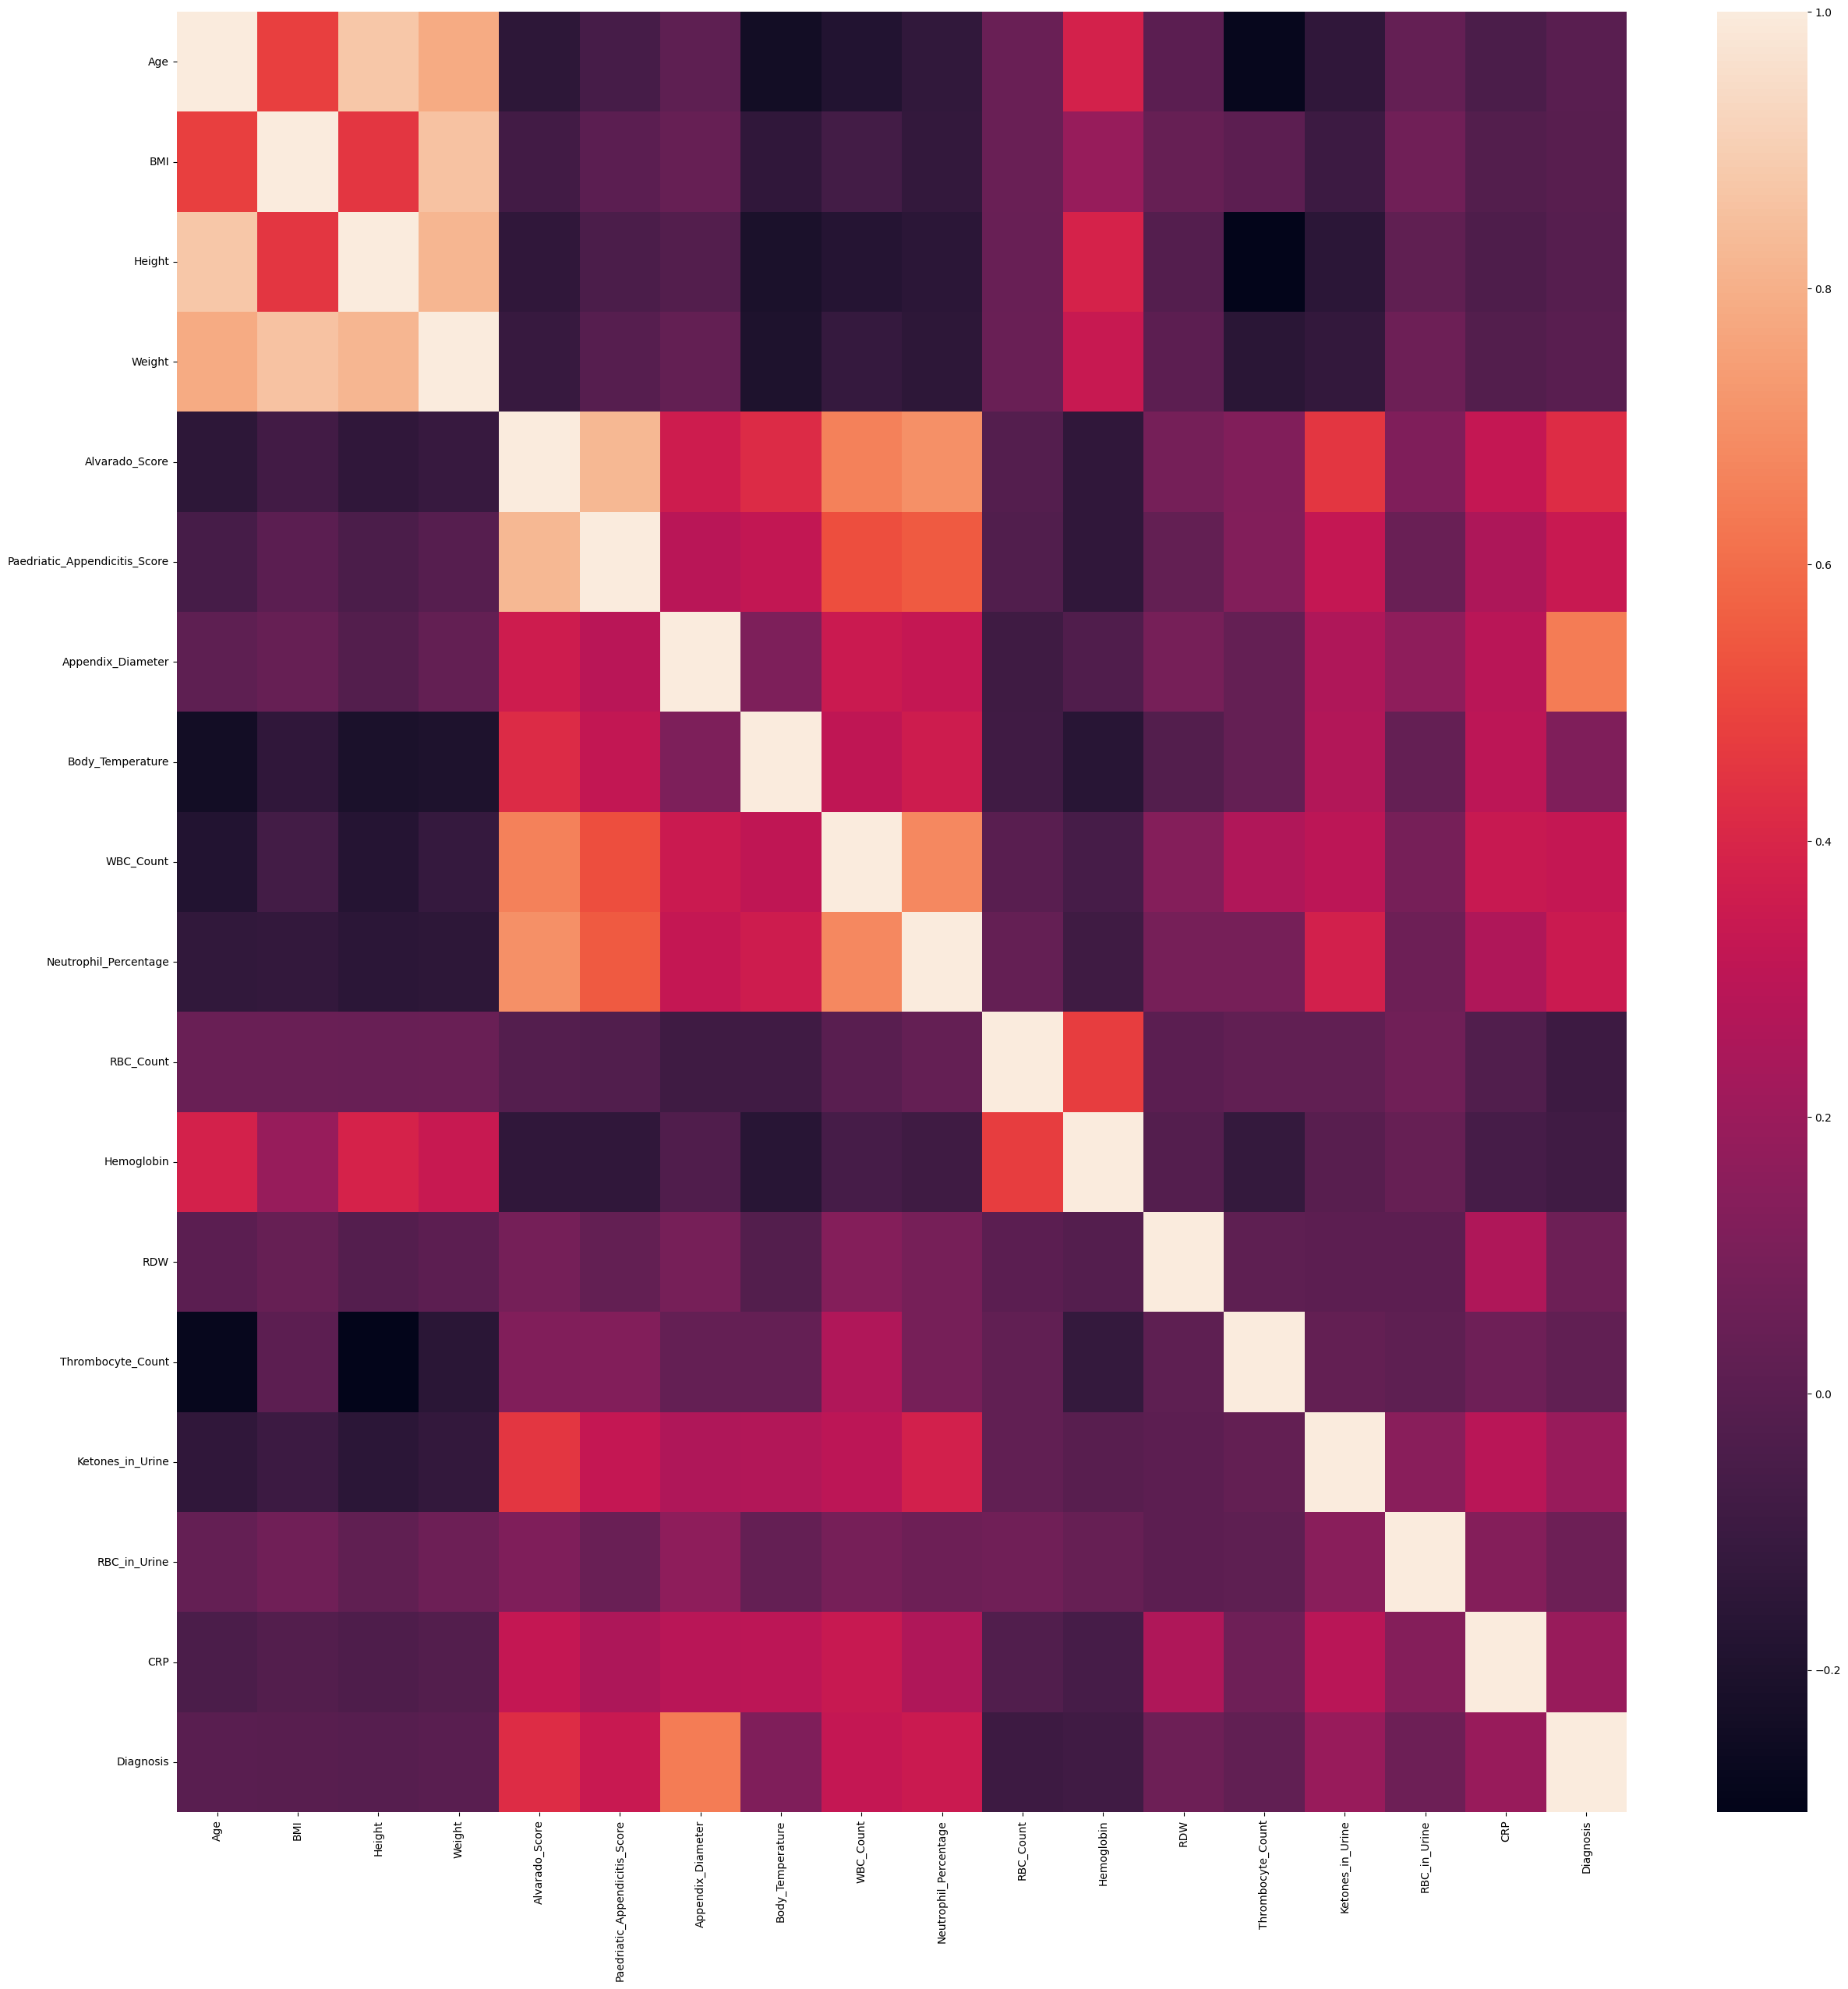

In [76]:
# preprocessing:


# removing the rows whose diagnosis column is nan
# df = df[df['Diagnosis'].notna()]
# df['Diagnosis'].value_counts(dropna = False)


# In[8]:


#converting the diagnosis value to int type
# df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)



# correlation of different columns with each other
df.corr()


# #  correlation of our output column with other columns
# df.corr()['Diagnosis']


# df


# # In[14]:


# #This is the list of other target or output columns
# target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]


# # In[15]:


# # REmoving other target columns since they are not necessary
# df.drop(target_cols,axis=1,inplace =True)


# # In[16]:


# #information of the remaining dataframe
# df.info()


# # In[17]:


# #removing the "Segmented_Neutrophils" Column, Since it had very few values
# df.drop("Segmented_Neutrophils",axis=1,inplace=True)


# # In[18]:


# df.info()


# <h2>Selecting only those rows which have no nan values : </h2>

# In[19]:


df2 = df.dropna().copy()


# In[20]:


df2


# In[21]:


df2.columns


# In[22]:


# df2["WBC_in_Urine"].value_counts()


# In[23]:


# df2["Sex"].value_counts()


# In[24]:


df2["Diagnosis"].value_counts()


# In[25]:


# df.info()


# In[26]:


# df2["Sex"].value_counts()


# In[27]:


# df2["Sex"] = (df["Sex"]=="male").astype(int)


# In[28]:


# df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)


# In[29]:


# df.info()


# In[30]:


# df2["Lower_Right_Abd_Pain"].value_counts()


# In[31]:


# df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
# df2["Lower_Right_Abd_Pain"].value_counts()


# In[32]:


# df2["Contralateral_Rebound_Tenderness"].value_counts()


# In[33]:


# df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
# df2['Contralateral_Rebound_Tenderness'].value_counts()


# In[34]:


# df2["Coughing_Pain"].value_counts(dropna = False)


# In[35]:


# df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
# df2["Coughing_Pain"].value_counts()


# In[36]:


# df2["Nausea"].value_counts(dropna = False)


# In[37]:


# df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
# df2["Nausea"].value_counts()


# In[38]:


# df2["Loss_of_Appetite"].value_counts(dropna= False)


# In[39]:


# df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
# df2["Loss_of_Appetite"].value_counts()


# In[40]:


# df2["Neutrophilia"].value_counts(dropna = False)


# In[41]:


# df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
# df2["Neutrophilia"].value_counts()


# In[42]:


df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[43]:


from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[44]:


df2.info()


# In[45]:


df2["RBC_in_Urine"].value_counts(dropna = False)


# In[46]:


enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)


# In[47]:


# df2["WBC_in_Urine"].value_counts(dropna= False)


# In[48]:


# enc = OrdinalEncoder(categories=[['no','+','++','+++']])
# enc.fit([['no'], ['+'], ['++'],['+++']])                                 
# df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
# df2["WBC_in_Urine"].value_counts(dropna = False)


# In[49]:


# df2["Dysuria"].value_counts(dropna= False)


# In[50]:


# df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
# df2["Dysuria"].value_counts()


# In[51]:


# df2["Stool"].value_counts()
#will do one hot encoding here


# In[52]:


# enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
# enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
# df2["Stool"] = enc.fit_transform(df2[["Stool"]])
# df2["Stool"].value_counts(dropna = False)


# In[53]:


# df2["Peritonitis"].value_counts()


# In[54]:


# enc = OrdinalEncoder(categories=[['no','local','generalized']])
# enc.fit([['no'], ['local'], ['generalized']])                                 
# df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
# df2["Peritonitis"].value_counts(dropna = False)


# In[55]:


# df2["Diagnosis"].corr(df2["Peritonitis"])


# In[56]:


#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)


# In[58]:


# df2["Diagnosis"].corr(df2["Peritonitis_binary"])


# In[59]:


# df2["Psoas_Sign"].value_counts()


# In[60]:


# df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)


# In[61]:


# df2["Ipsilateral_Rebound_Tenderness"].value_counts()


# In[62]:


# df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)


# In[63]:


df2.info()


# In[64]:


df2.corr()["Diagnosis"]


# In[65]:


plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())


# In[66]:


# df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)


# In[67]:


df2["Diagnosis"].value_counts()


In [77]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(318, 17)

In [78]:
y.value_counts()

1    230
0     88
Name: Diagnosis, dtype: int64

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [81]:
x_train.shape

(254, 17)

In [82]:
# y_train.value_counts()

In [83]:
# col
x_train.columns

Index(['Age', 'BMI', 'Height', 'Weight', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter',
       'Body_Temperature', 'WBC_Count', 'Neutrophil_Percentage', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'CRP'],
      dtype='object')

In [84]:
y_test.value_counts()
y_train.value_counts()

1    186
0     68
Name: Diagnosis, dtype: int64

In [85]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.54      0.35      0.42        20
           1       0.75      0.86      0.80        44

    accuracy                           0.70        64
   macro avg       0.64      0.61      0.61        64
weighted avg       0.68      0.70      0.68        64



In [86]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.05 ± 0.01
TEST_ACCURACY - Mean: 0.71 ± 0.05
TEST_F1 - Mean: 0.81 ± 0.04
TEST_ROC_AUC - Mean: 0.64 ± 0.08
TEST_AVERAGE_PRECISION - Mean: 0.79 ± 0.07
TEST_PRECISION - Mean: 0.77 ± 0.06
TEST_RECALL - Mean: 0.85 ± 0.02


In [87]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.8063
Fold 2: AUPR = 0.7450
Fold 3: AUPR = 0.8008
Fold 4: AUPR = 0.8531
Fold 5: AUPR = 0.9108

Average AUPR: 0.82 +- 0.06


In [88]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.52      0.75      0.61        20
           1       0.86      0.68      0.76        44

    accuracy                           0.70        64
   macro avg       0.69      0.72      0.69        64
weighted avg       0.75      0.70      0.71        64



In [89]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.74 ± 0.06
TEST_F1 - Mean: 0.80 ± 0.06
TEST_ROC_AUC - Mean: 0.87 ± 0.04
TEST_AVERAGE_PRECISION - Mean: 0.93 ± 0.05
TEST_PRECISION - Mean: 0.90 ± 0.07
TEST_RECALL - Mean: 0.71 ± 0.06


In [90]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9379
Fold 2: AUPR = 0.8239
Fold 3: AUPR = 0.9653
Fold 4: AUPR = 0.9670
Fold 5: AUPR = 0.9694

Average AUPR: 0.93 +- 0.06


In [91]:
from sklearn.svm import SVC
model = SVC()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.69      1.00      0.81        44

    accuracy                           0.69        64
   macro avg       0.34      0.50      0.41        64
weighted avg       0.47      0.69      0.56        64



C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [92]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.02 ± 0.00
SCORE_TIME - Mean: 0.04 ± 0.00
TEST_ACCURACY - Mean: 0.72 ± 0.05
TEST_F1 - Mean: 0.84 ± 0.04
TEST_ROC_AUC - Mean: 0.79 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.91 ± 0.04
TEST_PRECISION - Mean: 0.72 ± 0.05
TEST_RECALL - Mean: 1.00 ± 0.00


In [93]:
# This will not work here

# from sklearn.metrics import precision_recall_curve,auc
# def calc_aupr():
#     # Initialize list to store AUPR values for each fold
#     aupr_list = []
 
#     X = x
#     # Perform 5-fold cross-validation
#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         # Train the model
#         model.fit(X_train, y_train)

#         # Predict probabilities on the validation set
#         y_proba = model.predict_proba(X_test)

#         # Compute precision and recall
#         precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#         # Compute AUPR for the current fold
#         aupr = auc(recall, precision)

#         # Append AUPR to the list
#         aupr_list.append(aupr)

#     # Print AUPR values for each fold
#     for fold, aupr in enumerate(aupr_list, start=1):
#         print(f"Fold {fold}: AUPR = {aupr:.4f}")

#     # Calculate and print average AUPR over all folds
#     avg_aupr = np.mean(aupr_list)
#     std_aupr = np.std(aupr_list)
#     print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

# calc_aupr()

In [94]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.91      0.95      0.93        44

    accuracy                           0.91        64
   macro avg       0.90      0.88      0.89        64
weighted avg       0.91      0.91      0.90        64



In [95]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.93 ± 0.02
TEST_F1 - Mean: 0.95 ± 0.02
TEST_ROC_AUC - Mean: 0.92 ± 0.03
TEST_AVERAGE_PRECISION - Mean: 0.94 ± 0.03
TEST_PRECISION - Mean: 0.96 ± 0.03
TEST_RECALL - Mean: 0.95 ± 0.03


In [96]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9494
Fold 2: AUPR = 0.9392
Fold 3: AUPR = 0.9928
Fold 4: AUPR = 0.9894
Fold 5: AUPR = 0.9834

Average AUPR: 0.9708 +- 0.02


In [97]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       0.98      0.98      0.98        44

    accuracy                           0.97        64
   macro avg       0.96      0.96      0.96        64
weighted avg       0.97      0.97      0.97        64



In [98]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.48 ± 0.01
SCORE_TIME - Mean: 0.05 ± 0.00
TEST_ACCURACY - Mean: 0.93 ± 0.04
TEST_F1 - Mean: 0.95 ± 0.03
TEST_ROC_AUC - Mean: 0.98 ± 0.02
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01


In [99]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9940
Fold 2: AUPR = 0.9633
Fold 3: AUPR = 0.9983
Fold 4: AUPR = 0.9988
Fold 5: AUPR = 0.9982

Average AUPR: 0.9905 +- 0.01


In [100]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier()
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.95      0.95      0.95        44

    accuracy                           0.94        64
   macro avg       0.93      0.93      0.93        64
weighted avg       0.94      0.94      0.94        64



In [101]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x
# y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.10 ± 0.00
SCORE_TIME - Mean: 0.04 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.01
TEST_F1 - Mean: 0.96 ± 0.01
TEST_ROC_AUC - Mean: 0.98 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.00
TEST_PRECISION - Mean: 0.98 ± 0.02
TEST_RECALL - Mean: 0.94 ± 0.02


In [102]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9921
Fold 2: AUPR = 0.9862
Fold 3: AUPR = 0.9930
Fold 4: AUPR = 0.9987
Fold 5: AUPR = 0.9992

Average AUPR: 0.9939 +- 0.00


In [103]:
from lightgbm import LGBMClassifier
model = LGBMClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       0.98      0.98      0.98        44

    accuracy                           0.97        64
   macro avg       0.96      0.96      0.96        64
weighted avg       0.97      0.97      0.97        64



In [104]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.06 ± 0.01
SCORE_TIME - Mean: 0.03 ± 0.01
TEST_ACCURACY - Mean: 0.95 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.01
TEST_ROC_AUC - Mean: 0.98 ± 0.02
TEST_AVERAGE_PRECISION - Mean: 0.99 ± 0.01
TEST_PRECISION - Mean: 0.97 ± 0.03
TEST_RECALL - Mean: 0.96 ± 0.02


In [105]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.9915 ± 0.01


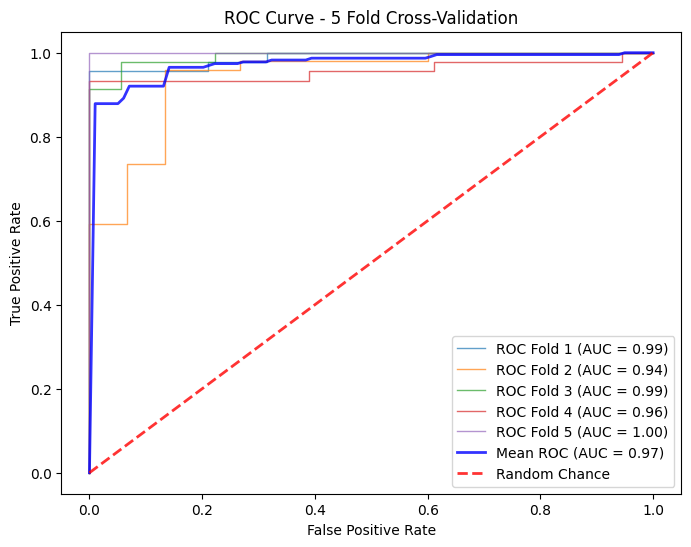

In [106]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [107]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        20
           1       0.95      0.95      0.95        44

    accuracy                           0.94        64
   macro avg       0.93      0.93      0.93        64
weighted avg       0.94      0.94      0.94        64



In [108]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.30 ± 0.01
SCORE_TIME - Mean: 0.07 ± 0.00
TEST_ACCURACY - Mean: 0.63 ± 0.04
TEST_F1 - Mean: 0.75 ± 0.03
TEST_ROC_AUC - Mean: 0.45 ± 0.07
TEST_AVERAGE_PRECISION - Mean: 0.72 ± 0.05
TEST_PRECISION - Mean: 0.72 ± 0.03
TEST_RECALL - Mean: 0.80 ± 0.05


In [109]:
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score
import numpy as np

# Assuming you have your data and model ready
# X = your_data  # Features
# y = your_labels  # Target variable
X = x
# X = pd.DataFrame(X)
# y = pd.DataFrame(y)
def calulatuion():
    # Initialize KFold with 5 folds
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    aupr_scores = []  # List to store AUPR scores for each fold

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Fit your model
        model.fit(X_train, y_train)

        # Predict probabilities for positive class
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Calculate AUPR for this fold
        aupr = average_precision_score(y_test, y_pred_proba)
        aupr_scores.append(aupr)

    # Calculate average AUPR across all folds
    average_aupr = np.mean(aupr_scores)
    std_aupr = np.std(aupr_scores)

    print(f'Average AUPR: {average_aupr:.4f} ± {std_aupr:.2f}')
calulatuion()

Average AUPR: 0.7179 ± 0.05


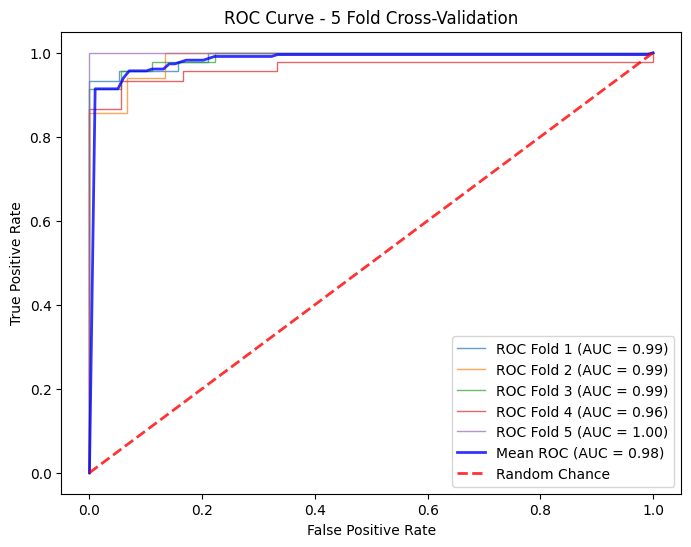

In [110]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [111]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.90      0.95      0.92        19
           1       0.98      0.96      0.97        45

    accuracy                           0.95        64
   macro avg       0.94      0.95      0.94        64
weighted avg       0.95      0.95      0.95        64



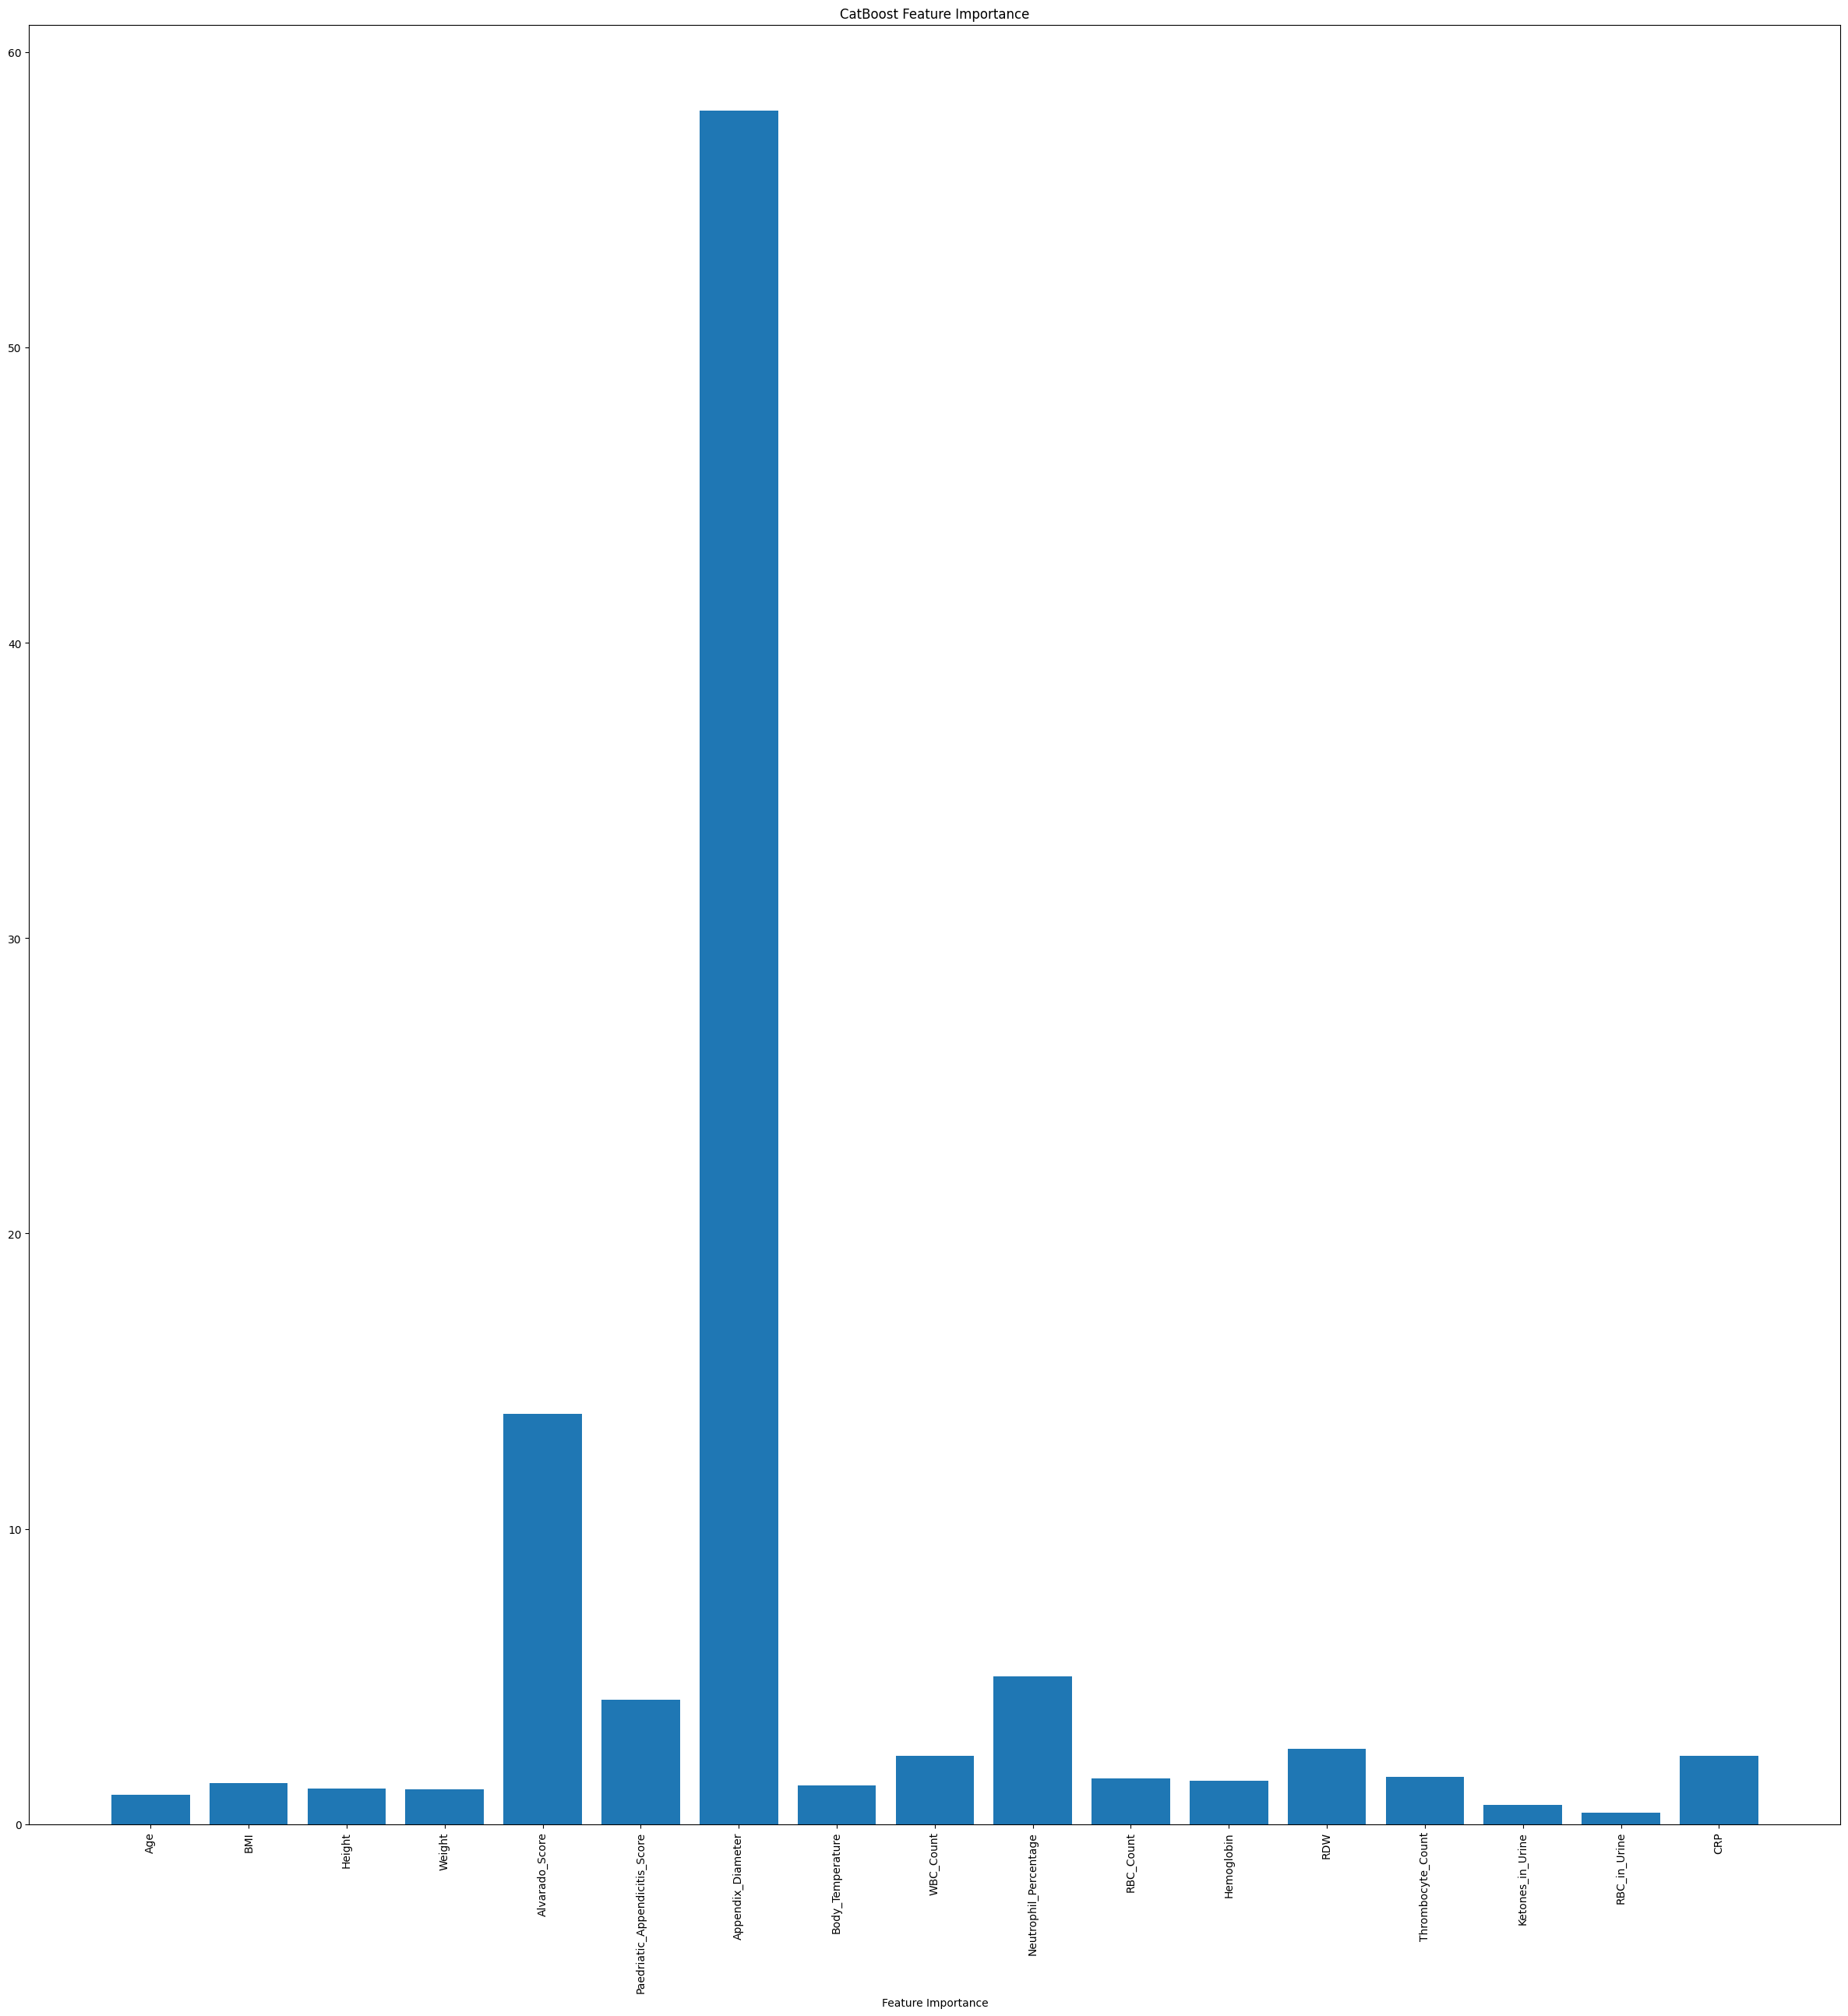

In [112]:
import matplotlib.pyplot as plt    
feature_importance = model.get_feature_importance()
feature_names = X.columns 
plt.figure(figsize=(30,30))
plt.bar(feature_names, feature_importance) 
plt.xlabel("Feature Importance") 
plt.title("CatBoost Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [113]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6900284	total: 6.68ms	remaining: 10s
1:	learn: 0.6874134	total: 12.7ms	remaining: 9.53s
2:	learn: 0.6844853	total: 19.1ms	remaining: 9.54s
3:	learn: 0.6812097	total: 25ms	remaining: 9.35s
4:	learn: 0.6780785	total: 30.8ms	remaining: 9.21s
5:	learn: 0.6754347	total: 36.5ms	remaining: 9.09s
6:	learn: 0.6722570	total: 42.3ms	remaining: 9.01s
7:	learn: 0.6697657	total: 49.5ms	remaining: 9.22s
8:	learn: 0.6672724	total: 56.2ms	remaining: 9.32s
9:	learn: 0.6650087	total: 62.1ms	remaining: 9.25s
10:	learn: 0.6622491	total: 67.5ms	remaining: 9.14s
11:	learn: 0.6585270	total: 73.8ms	remaining: 9.15s
12:	learn: 0.6560585	total: 80.6ms	remaining: 9.22s
13:	learn: 0.6539116	total: 86ms	remaining: 9.13s
14:	learn: 0.6511011	total: 92.6ms	remaining: 9.16s
15:	learn: 0.6486451	total: 97.6ms	remaining: 9.05s
16:	learn: 0.6462312	total: 104ms	remaining: 9.08s
17:	learn: 0.6442307	total: 110ms	remaining: 9.04s
18:	learn: 0.6414911	total: 117ms	remaining: 9.1s
19:	learn: 0.6389489	total: 122m

170:	learn: 0.4463316	total: 988ms	remaining: 7.68s
171:	learn: 0.4457830	total: 994ms	remaining: 7.67s
172:	learn: 0.4449255	total: 999ms	remaining: 7.67s
173:	learn: 0.4438940	total: 1s	remaining: 7.66s
174:	learn: 0.4432059	total: 1.01s	remaining: 7.66s
175:	learn: 0.4424769	total: 1.02s	remaining: 7.65s
176:	learn: 0.4418648	total: 1.02s	remaining: 7.66s
177:	learn: 0.4410039	total: 1.03s	remaining: 7.66s
178:	learn: 0.4400865	total: 1.04s	remaining: 7.67s
179:	learn: 0.4389287	total: 1.04s	remaining: 7.66s
180:	learn: 0.4384899	total: 1.05s	remaining: 7.64s
181:	learn: 0.4376703	total: 1.05s	remaining: 7.64s
182:	learn: 0.4363099	total: 1.06s	remaining: 7.63s
183:	learn: 0.4354873	total: 1.06s	remaining: 7.62s
184:	learn: 0.4344279	total: 1.07s	remaining: 7.61s
185:	learn: 0.4336899	total: 1.08s	remaining: 7.61s
186:	learn: 0.4329557	total: 1.08s	remaining: 7.61s
187:	learn: 0.4320279	total: 1.09s	remaining: 7.6s
188:	learn: 0.4315631	total: 1.09s	remaining: 7.59s
189:	learn: 0.43

338:	learn: 0.3440259	total: 1.98s	remaining: 6.79s
339:	learn: 0.3431777	total: 1.99s	remaining: 6.79s
340:	learn: 0.3426311	total: 2s	remaining: 6.78s
341:	learn: 0.3422079	total: 2s	remaining: 6.77s
342:	learn: 0.3419423	total: 2.01s	remaining: 6.77s
343:	learn: 0.3408912	total: 2.01s	remaining: 6.76s
344:	learn: 0.3403504	total: 2.02s	remaining: 6.76s
345:	learn: 0.3398083	total: 2.02s	remaining: 6.75s
346:	learn: 0.3394066	total: 2.03s	remaining: 6.75s
347:	learn: 0.3386545	total: 2.04s	remaining: 6.74s
348:	learn: 0.3383081	total: 2.04s	remaining: 6.73s
349:	learn: 0.3378810	total: 2.05s	remaining: 6.72s
350:	learn: 0.3376257	total: 2.05s	remaining: 6.72s
351:	learn: 0.3371425	total: 2.06s	remaining: 6.71s
352:	learn: 0.3366040	total: 2.06s	remaining: 6.7s
353:	learn: 0.3361286	total: 2.07s	remaining: 6.7s
354:	learn: 0.3359566	total: 2.07s	remaining: 6.69s
355:	learn: 0.3357877	total: 2.08s	remaining: 6.68s
356:	learn: 0.3353692	total: 2.08s	remaining: 6.68s
357:	learn: 0.335007

510:	learn: 0.2666857	total: 2.97s	remaining: 5.74s
511:	learn: 0.2661979	total: 2.97s	remaining: 5.74s
512:	learn: 0.2657896	total: 2.98s	remaining: 5.73s
513:	learn: 0.2657156	total: 2.98s	remaining: 5.72s
514:	learn: 0.2652053	total: 2.99s	remaining: 5.72s
515:	learn: 0.2651919	total: 3s	remaining: 5.71s
516:	learn: 0.2646867	total: 3s	remaining: 5.71s
517:	learn: 0.2643471	total: 3.01s	remaining: 5.7s
518:	learn: 0.2640140	total: 3.01s	remaining: 5.7s
519:	learn: 0.2636699	total: 3.02s	remaining: 5.69s
520:	learn: 0.2631926	total: 3.02s	remaining: 5.68s
521:	learn: 0.2628532	total: 3.03s	remaining: 5.68s
522:	learn: 0.2625576	total: 3.04s	remaining: 5.67s
523:	learn: 0.2619020	total: 3.04s	remaining: 5.66s
524:	learn: 0.2615241	total: 3.05s	remaining: 5.66s
525:	learn: 0.2608864	total: 3.05s	remaining: 5.65s
526:	learn: 0.2606166	total: 3.06s	remaining: 5.64s
527:	learn: 0.2604297	total: 3.06s	remaining: 5.64s
528:	learn: 0.2600105	total: 3.07s	remaining: 5.63s
529:	learn: 0.259562

686:	learn: 0.2052791	total: 3.94s	remaining: 4.66s
687:	learn: 0.2049701	total: 3.95s	remaining: 4.66s
688:	learn: 0.2047407	total: 3.95s	remaining: 4.65s
689:	learn: 0.2043466	total: 3.96s	remaining: 4.64s
690:	learn: 0.2039092	total: 3.96s	remaining: 4.64s
691:	learn: 0.2036057	total: 3.97s	remaining: 4.63s
692:	learn: 0.2035147	total: 3.98s	remaining: 4.63s
693:	learn: 0.2028484	total: 3.98s	remaining: 4.62s
694:	learn: 0.2024385	total: 3.98s	remaining: 4.62s
695:	learn: 0.2021672	total: 3.99s	remaining: 4.61s
696:	learn: 0.2019220	total: 3.99s	remaining: 4.6s
697:	learn: 0.2015639	total: 4s	remaining: 4.59s
698:	learn: 0.2015132	total: 4s	remaining: 4.58s
699:	learn: 0.2013883	total: 4.01s	remaining: 4.58s
700:	learn: 0.2008854	total: 4.01s	remaining: 4.57s
701:	learn: 0.2003272	total: 4.02s	remaining: 4.57s
702:	learn: 0.2001959	total: 4.02s	remaining: 4.56s
703:	learn: 0.1998303	total: 4.03s	remaining: 4.55s
704:	learn: 0.1995359	total: 4.03s	remaining: 4.55s
705:	learn: 0.19914

...

678:	learn: 0.2128018	total: 3.98s	remaining: 4.81s
679:	learn: 0.2125046	total: 3.99s	remaining: 4.81s
680:	learn: 0.2124302	total: 3.99s	remaining: 4.8s
681:	learn: 0.2120465	total: 4s	remaining: 4.79s
682:	learn: 0.2117134	total: 4s	remaining: 4.79s
683:	learn: 0.2116534	total: 4.01s	remaining: 4.78s
684:	learn: 0.2115335	total: 4.01s	remaining: 4.78s
685:	learn: 0.2110991	total: 4.02s	remaining: 4.77s
686:	learn: 0.2108497	total: 4.03s	remaining: 4.76s
687:	learn: 0.2104341	total: 4.03s	remaining: 4.76s
688:	learn: 0.2102629	total: 4.04s	remaining: 4.75s
689:	learn: 0.2099872	total: 4.04s	remaining: 4.75s
690:	learn: 0.2098658	total: 4.05s	remaining: 4.74s
691:	learn: 0.2097060	total: 4.06s	remaining: 4.74s
692:	learn: 0.2093724	total: 4.07s	remaining: 4.74s
693:	learn: 0.2087954	total: 4.07s	remaining: 4.73s
694:	learn: 0.2084020	total: 4.08s	remaining: 4.72s
695:	learn: 0.2081804	total: 4.09s	remaining: 4.72s
696:	learn: 0.2079650	total: 4.09s	remaining: 4.71s
697:	learn: 0.20772

849:	learn: 0.1662755	total: 4.96s	remaining: 3.79s
850:	learn: 0.1662531	total: 4.97s	remaining: 3.79s
851:	learn: 0.1659204	total: 4.98s	remaining: 3.78s
852:	learn: 0.1653057	total: 4.98s	remaining: 3.78s
853:	learn: 0.1649216	total: 4.99s	remaining: 3.77s
854:	learn: 0.1646495	total: 4.99s	remaining: 3.77s
855:	learn: 0.1643016	total: 5s	remaining: 3.76s
856:	learn: 0.1640086	total: 5s	remaining: 3.75s
857:	learn: 0.1637030	total: 5.01s	remaining: 3.75s
858:	learn: 0.1633337	total: 5.02s	remaining: 3.74s
859:	learn: 0.1630544	total: 5.02s	remaining: 3.74s
860:	learn: 0.1625210	total: 5.03s	remaining: 3.73s
861:	learn: 0.1620870	total: 5.03s	remaining: 3.73s
862:	learn: 0.1616941	total: 5.04s	remaining: 3.72s
863:	learn: 0.1616159	total: 5.05s	remaining: 3.71s
864:	learn: 0.1612622	total: 5.05s	remaining: 3.71s
865:	learn: 0.1610042	total: 5.06s	remaining: 3.7s
866:	learn: 0.1606701	total: 5.06s	remaining: 3.7s
867:	learn: 0.1603882	total: 5.07s	remaining: 3.69s
868:	learn: 0.160128

1023:	learn: 0.1264225	total: 5.95s	remaining: 2.76s
1024:	learn: 0.1262331	total: 5.95s	remaining: 2.76s
1025:	learn: 0.1261097	total: 5.96s	remaining: 2.75s
1026:	learn: 0.1259166	total: 5.96s	remaining: 2.75s
1027:	learn: 0.1258992	total: 5.97s	remaining: 2.74s
1028:	learn: 0.1255890	total: 5.97s	remaining: 2.73s
1029:	learn: 0.1254770	total: 5.98s	remaining: 2.73s
1030:	learn: 0.1253562	total: 5.99s	remaining: 2.72s
1031:	learn: 0.1250598	total: 5.99s	remaining: 2.72s
1032:	learn: 0.1250453	total: 6s	remaining: 2.71s
1033:	learn: 0.1248444	total: 6s	remaining: 2.71s
1034:	learn: 0.1247235	total: 6.01s	remaining: 2.7s
1035:	learn: 0.1244078	total: 6.01s	remaining: 2.69s
1036:	learn: 0.1241791	total: 6.02s	remaining: 2.69s
1037:	learn: 0.1239132	total: 6.02s	remaining: 2.68s
1038:	learn: 0.1237036	total: 6.03s	remaining: 2.67s
1039:	learn: 0.1235702	total: 6.04s	remaining: 2.67s
1040:	learn: 0.1234140	total: 6.04s	remaining: 2.66s
1041:	learn: 0.1231759	total: 6.05s	remaining: 2.66s


1198:	learn: 0.0995258	total: 6.95s	remaining: 1.75s
1199:	learn: 0.0994279	total: 6.96s	remaining: 1.74s
1200:	learn: 0.0993733	total: 6.96s	remaining: 1.73s
1201:	learn: 0.0992231	total: 6.97s	remaining: 1.73s
1202:	learn: 0.0991766	total: 6.98s	remaining: 1.72s
1203:	learn: 0.0990929	total: 6.98s	remaining: 1.72s
1204:	learn: 0.0989164	total: 6.99s	remaining: 1.71s
1205:	learn: 0.0988712	total: 7s	remaining: 1.71s
1206:	learn: 0.0985743	total: 7s	remaining: 1.7s
1207:	learn: 0.0984673	total: 7.01s	remaining: 1.69s
1208:	learn: 0.0984248	total: 7.01s	remaining: 1.69s
1209:	learn: 0.0982209	total: 7.02s	remaining: 1.68s
1210:	learn: 0.0981472	total: 7.02s	remaining: 1.68s
1211:	learn: 0.0979613	total: 7.03s	remaining: 1.67s
1212:	learn: 0.0979524	total: 7.04s	remaining: 1.67s
1213:	learn: 0.0978029	total: 7.05s	remaining: 1.66s
1214:	learn: 0.0976642	total: 7.05s	remaining: 1.65s
1215:	learn: 0.0976146	total: 7.06s	remaining: 1.65s
1216:	learn: 0.0975090	total: 7.07s	remaining: 1.64s


1364:	learn: 0.0807839	total: 7.94s	remaining: 785ms
1365:	learn: 0.0807335	total: 7.95s	remaining: 780ms
1366:	learn: 0.0805672	total: 7.95s	remaining: 774ms
1367:	learn: 0.0805549	total: 7.96s	remaining: 768ms
1368:	learn: 0.0804891	total: 7.96s	remaining: 762ms
1369:	learn: 0.0803516	total: 7.97s	remaining: 756ms
1370:	learn: 0.0802712	total: 7.98s	remaining: 751ms
1371:	learn: 0.0801152	total: 7.98s	remaining: 745ms
1372:	learn: 0.0800384	total: 7.99s	remaining: 739ms
1373:	learn: 0.0799185	total: 8s	remaining: 733ms
1374:	learn: 0.0797762	total: 8s	remaining: 728ms
1375:	learn: 0.0796291	total: 8.01s	remaining: 722ms
1376:	learn: 0.0794683	total: 8.02s	remaining: 716ms
1377:	learn: 0.0793709	total: 8.03s	remaining: 711ms
1378:	learn: 0.0792501	total: 8.03s	remaining: 705ms
1379:	learn: 0.0792409	total: 8.04s	remaining: 699ms
1380:	learn: 0.0791529	total: 8.04s	remaining: 693ms
1381:	learn: 0.0789927	total: 8.05s	remaining: 688ms
1382:	learn: 0.0788904	total: 8.06s	remaining: 682ms

In [114]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

0:	learn: 0.6900284	total: 6.02ms	remaining: 9.02s
1:	learn: 0.6874134	total: 12.2ms	remaining: 9.1s
2:	learn: 0.6844853	total: 18.8ms	remaining: 9.37s
3:	learn: 0.6812097	total: 24.4ms	remaining: 9.12s
4:	learn: 0.6780785	total: 30.1ms	remaining: 9s
5:	learn: 0.6754347	total: 35.4ms	remaining: 8.8s
6:	learn: 0.6722570	total: 40.9ms	remaining: 8.73s
7:	learn: 0.6697657	total: 46.7ms	remaining: 8.72s
8:	learn: 0.6672724	total: 52.3ms	remaining: 8.66s
9:	learn: 0.6650087	total: 58.5ms	remaining: 8.71s
10:	learn: 0.6622491	total: 64.5ms	remaining: 8.73s
11:	learn: 0.6585270	total: 70.6ms	remaining: 8.76s
12:	learn: 0.6560585	total: 76.1ms	remaining: 8.7s
13:	learn: 0.6539116	total: 81.5ms	remaining: 8.65s
14:	learn: 0.6511011	total: 88.3ms	remaining: 8.74s
15:	learn: 0.6486451	total: 93.9ms	remaining: 8.71s
16:	learn: 0.6462312	total: 100ms	remaining: 8.72s
17:	learn: 0.6442307	total: 106ms	remaining: 8.7s
18:	learn: 0.6414911	total: 111ms	remaining: 8.64s
19:	learn: 0.6389489	total: 117m

167:	learn: 0.4490254	total: 999ms	remaining: 7.92s
168:	learn: 0.4481863	total: 1s	remaining: 7.92s
169:	learn: 0.4469294	total: 1.01s	remaining: 7.92s
170:	learn: 0.4463316	total: 1.02s	remaining: 7.91s
171:	learn: 0.4457830	total: 1.02s	remaining: 7.91s
172:	learn: 0.4449255	total: 1.03s	remaining: 7.92s
173:	learn: 0.4438940	total: 1.04s	remaining: 7.92s
174:	learn: 0.4432059	total: 1.04s	remaining: 7.91s
175:	learn: 0.4424769	total: 1.05s	remaining: 7.9s
176:	learn: 0.4418648	total: 1.06s	remaining: 7.9s
177:	learn: 0.4410039	total: 1.06s	remaining: 7.9s
178:	learn: 0.4400865	total: 1.07s	remaining: 7.9s
179:	learn: 0.4389287	total: 1.08s	remaining: 7.9s
180:	learn: 0.4384899	total: 1.08s	remaining: 7.89s
181:	learn: 0.4376703	total: 1.09s	remaining: 7.89s
182:	learn: 0.4363099	total: 1.1s	remaining: 7.89s
183:	learn: 0.4354873	total: 1.1s	remaining: 7.89s
184:	learn: 0.4344279	total: 1.11s	remaining: 7.9s
185:	learn: 0.4336899	total: 1.12s	remaining: 7.89s
186:	learn: 0.4329557	t

332:	learn: 0.3468518	total: 1.97s	remaining: 6.92s
333:	learn: 0.3462620	total: 1.98s	remaining: 6.91s
334:	learn: 0.3459187	total: 1.99s	remaining: 6.91s
335:	learn: 0.3455164	total: 1.99s	remaining: 6.9s
336:	learn: 0.3453506	total: 2s	remaining: 6.89s
337:	learn: 0.3450024	total: 2s	remaining: 6.89s
338:	learn: 0.3440259	total: 2.01s	remaining: 6.88s
339:	learn: 0.3431777	total: 2.02s	remaining: 6.88s
340:	learn: 0.3426311	total: 2.02s	remaining: 6.87s
341:	learn: 0.3422079	total: 2.03s	remaining: 6.87s
342:	learn: 0.3419423	total: 2.03s	remaining: 6.86s
343:	learn: 0.3408912	total: 2.04s	remaining: 6.86s
344:	learn: 0.3403504	total: 2.05s	remaining: 6.85s
345:	learn: 0.3398083	total: 2.06s	remaining: 6.85s
346:	learn: 0.3394066	total: 2.06s	remaining: 6.85s
347:	learn: 0.3386545	total: 2.07s	remaining: 6.85s
348:	learn: 0.3383081	total: 2.07s	remaining: 6.84s
349:	learn: 0.3378810	total: 2.08s	remaining: 6.84s
350:	learn: 0.3376257	total: 2.09s	remaining: 6.83s
351:	learn: 0.33714

514:	learn: 0.2652053	total: 3.15s	remaining: 6.02s
515:	learn: 0.2651919	total: 3.15s	remaining: 6.01s
516:	learn: 0.2646867	total: 3.16s	remaining: 6.01s
517:	learn: 0.2643471	total: 3.17s	remaining: 6s
518:	learn: 0.2640140	total: 3.17s	remaining: 6s
519:	learn: 0.2636699	total: 3.18s	remaining: 5.99s
520:	learn: 0.2631926	total: 3.19s	remaining: 5.99s
521:	learn: 0.2628532	total: 3.19s	remaining: 5.98s
522:	learn: 0.2625576	total: 3.2s	remaining: 5.98s
523:	learn: 0.2619020	total: 3.21s	remaining: 5.97s
524:	learn: 0.2615241	total: 3.21s	remaining: 5.96s
525:	learn: 0.2608864	total: 3.22s	remaining: 5.96s
526:	learn: 0.2606166	total: 3.22s	remaining: 5.95s
527:	learn: 0.2604297	total: 3.23s	remaining: 5.94s
528:	learn: 0.2600105	total: 3.23s	remaining: 5.94s
529:	learn: 0.2595623	total: 3.24s	remaining: 5.93s
530:	learn: 0.2590003	total: 3.25s	remaining: 5.93s
531:	learn: 0.2585916	total: 3.25s	remaining: 5.92s
532:	learn: 0.2581433	total: 3.26s	remaining: 5.92s
533:	learn: 0.25767

702:	learn: 0.2001959	total: 4.34s	remaining: 4.92s
703:	learn: 0.1998303	total: 4.35s	remaining: 4.91s
704:	learn: 0.1995359	total: 4.35s	remaining: 4.91s
705:	learn: 0.1991485	total: 4.36s	remaining: 4.9s
706:	learn: 0.1990216	total: 4.37s	remaining: 4.9s
707:	learn: 0.1988605	total: 4.37s	remaining: 4.89s
708:	learn: 0.1984924	total: 4.38s	remaining: 4.88s
709:	learn: 0.1983335	total: 4.38s	remaining: 4.88s
710:	learn: 0.1977621	total: 4.39s	remaining: 4.87s
711:	learn: 0.1974462	total: 4.4s	remaining: 4.87s
712:	learn: 0.1970144	total: 4.4s	remaining: 4.86s
713:	learn: 0.1966960	total: 4.41s	remaining: 4.85s
714:	learn: 0.1966451	total: 4.42s	remaining: 4.85s
715:	learn: 0.1962361	total: 4.42s	remaining: 4.84s
716:	learn: 0.1958317	total: 4.43s	remaining: 4.83s
717:	learn: 0.1954319	total: 4.43s	remaining: 4.83s
718:	learn: 0.1951808	total: 4.44s	remaining: 4.82s
719:	learn: 0.1945646	total: 4.45s	remaining: 4.82s
720:	learn: 0.1940864	total: 4.45s	remaining: 4.81s
721:	learn: 0.19

...

721:	learn: 0.2015262	total: 3.82s	remaining: 4.11s
722:	learn: 0.2011656	total: 3.82s	remaining: 4.11s
723:	learn: 0.2008763	total: 3.83s	remaining: 4.1s
724:	learn: 0.2006752	total: 3.83s	remaining: 4.1s
725:	learn: 0.2002941	total: 3.84s	remaining: 4.09s
726:	learn: 0.1998529	total: 3.84s	remaining: 4.09s
727:	learn: 0.1997226	total: 3.85s	remaining: 4.08s
728:	learn: 0.1989521	total: 3.85s	remaining: 4.08s
729:	learn: 0.1989114	total: 3.86s	remaining: 4.07s
730:	learn: 0.1988376	total: 3.86s	remaining: 4.07s
731:	learn: 0.1985435	total: 3.87s	remaining: 4.06s
732:	learn: 0.1985192	total: 3.87s	remaining: 4.05s
733:	learn: 0.1984931	total: 3.88s	remaining: 4.05s
734:	learn: 0.1982483	total: 3.88s	remaining: 4.04s
735:	learn: 0.1978152	total: 3.89s	remaining: 4.04s
736:	learn: 0.1977079	total: 3.9s	remaining: 4.03s
737:	learn: 0.1976376	total: 3.9s	remaining: 4.03s
738:	learn: 0.1971912	total: 3.9s	remaining: 4.02s
739:	learn: 0.1968695	total: 3.91s	remaining: 4.02s
740:	learn: 0.196

888:	learn: 0.1548634	total: 4.79s	remaining: 3.3s
889:	learn: 0.1545905	total: 4.8s	remaining: 3.29s
890:	learn: 0.1543769	total: 4.81s	remaining: 3.29s
891:	learn: 0.1541055	total: 4.81s	remaining: 3.28s
892:	learn: 0.1538647	total: 4.82s	remaining: 3.28s
893:	learn: 0.1537393	total: 4.83s	remaining: 3.27s
894:	learn: 0.1536956	total: 4.83s	remaining: 3.27s
895:	learn: 0.1535124	total: 4.84s	remaining: 3.26s
896:	learn: 0.1534915	total: 4.84s	remaining: 3.25s
897:	learn: 0.1532406	total: 4.85s	remaining: 3.25s
898:	learn: 0.1532179	total: 4.85s	remaining: 3.24s
899:	learn: 0.1529780	total: 4.86s	remaining: 3.24s
900:	learn: 0.1526780	total: 4.86s	remaining: 3.23s
901:	learn: 0.1523601	total: 4.87s	remaining: 3.23s
902:	learn: 0.1521180	total: 4.87s	remaining: 3.22s
903:	learn: 0.1517732	total: 4.88s	remaining: 3.22s
904:	learn: 0.1515402	total: 4.88s	remaining: 3.21s
905:	learn: 0.1512757	total: 4.89s	remaining: 3.2s
906:	learn: 0.1512382	total: 4.89s	remaining: 3.2s
907:	learn: 0.15

1073:	learn: 0.1174067	total: 5.99s	remaining: 2.37s
1074:	learn: 0.1173914	total: 5.99s	remaining: 2.37s
1075:	learn: 0.1173751	total: 6s	remaining: 2.36s
1076:	learn: 0.1170542	total: 6s	remaining: 2.36s
1077:	learn: 0.1169976	total: 6.01s	remaining: 2.35s
1078:	learn: 0.1169168	total: 6.02s	remaining: 2.35s
1079:	learn: 0.1167471	total: 6.02s	remaining: 2.34s
1080:	learn: 0.1167296	total: 6.03s	remaining: 2.34s
1081:	learn: 0.1165931	total: 6.04s	remaining: 2.33s
1082:	learn: 0.1163575	total: 6.04s	remaining: 2.33s
1083:	learn: 0.1160340	total: 6.05s	remaining: 2.32s
1084:	learn: 0.1159467	total: 6.05s	remaining: 2.31s
1085:	learn: 0.1158081	total: 6.06s	remaining: 2.31s
1086:	learn: 0.1155992	total: 6.07s	remaining: 2.31s
1087:	learn: 0.1155749	total: 6.08s	remaining: 2.3s
1088:	learn: 0.1154664	total: 6.08s	remaining: 2.3s
1089:	learn: 0.1154389	total: 6.09s	remaining: 2.29s
1090:	learn: 0.1151554	total: 6.1s	remaining: 2.29s
1091:	learn: 0.1149144	total: 6.11s	remaining: 2.28s
10

1238:	learn: 0.0947113	total: 6.96s	remaining: 1.47s
1239:	learn: 0.0946052	total: 6.97s	remaining: 1.46s
1240:	learn: 0.0944203	total: 6.97s	remaining: 1.46s
1241:	learn: 0.0941887	total: 6.98s	remaining: 1.45s
1242:	learn: 0.0939541	total: 6.99s	remaining: 1.44s
1243:	learn: 0.0938070	total: 6.99s	remaining: 1.44s
1244:	learn: 0.0935446	total: 7s	remaining: 1.43s
1245:	learn: 0.0933886	total: 7s	remaining: 1.43s
1246:	learn: 0.0933330	total: 7.01s	remaining: 1.42s
1247:	learn: 0.0932215	total: 7.01s	remaining: 1.42s
1248:	learn: 0.0931064	total: 7.02s	remaining: 1.41s
1249:	learn: 0.0930261	total: 7.02s	remaining: 1.4s
1250:	learn: 0.0929576	total: 7.03s	remaining: 1.4s
1251:	learn: 0.0928274	total: 7.03s	remaining: 1.39s
1252:	learn: 0.0928163	total: 7.04s	remaining: 1.39s
1253:	learn: 0.0927389	total: 7.04s	remaining: 1.38s
1254:	learn: 0.0927210	total: 7.05s	remaining: 1.38s
1255:	learn: 0.0925112	total: 7.05s	remaining: 1.37s
1256:	learn: 0.0923466	total: 7.05s	remaining: 1.36s
1

1429:	learn: 0.0749827	total: 7.95s	remaining: 389ms
1430:	learn: 0.0749763	total: 7.96s	remaining: 384ms
1431:	learn: 0.0748585	total: 7.96s	remaining: 378ms
1432:	learn: 0.0748516	total: 7.97s	remaining: 373ms
1433:	learn: 0.0746977	total: 7.97s	remaining: 367ms
1434:	learn: 0.0745669	total: 7.98s	remaining: 361ms
1435:	learn: 0.0744755	total: 7.98s	remaining: 356ms
1436:	learn: 0.0743703	total: 7.99s	remaining: 350ms
1437:	learn: 0.0743631	total: 7.99s	remaining: 345ms
1438:	learn: 0.0743571	total: 8s	remaining: 339ms
1439:	learn: 0.0742472	total: 8s	remaining: 333ms
1440:	learn: 0.0741665	total: 8.01s	remaining: 328ms
1441:	learn: 0.0741527	total: 8.01s	remaining: 322ms
1442:	learn: 0.0739641	total: 8.02s	remaining: 317ms
1443:	learn: 0.0738523	total: 8.02s	remaining: 311ms
1444:	learn: 0.0737989	total: 8.03s	remaining: 306ms
1445:	learn: 0.0736326	total: 8.03s	remaining: 300ms
1446:	learn: 0.0735224	total: 8.04s	remaining: 294ms
1447:	learn: 0.0733858	total: 8.04s	remaining: 289ms

In [115]:
# calculating auc for 5 folds : lagaing dimaaaaag

from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
# scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)
score = cross_val_score(model,X,y,scoring = 'roc_auc')

print(score)

# for value in scores:
#     v = str(value)
#     mean_score = scores[v].mean()
#     std_score = scores[v].std()
#     print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6771604	total: 6.54ms	remaining: 9.8s
1:	learn: 0.6654377	total: 12.6ms	remaining: 9.47s
2:	learn: 0.6536173	total: 18.1ms	remaining: 9.02s
3:	learn: 0.6358063	total: 23.7ms	remaining: 8.85s
4:	learn: 0.6250490	total: 29ms	remaining: 8.66s
5:	learn: 0.6139067	total: 34.4ms	remaining: 8.56s
6:	learn: 0.6013027	total: 39.8ms	remaining: 8.48s
7:	learn: 0.5859179	total: 45ms	remaining: 8.4s
8:	learn: 0.5749898	total: 50.1ms	remaining: 8.29s
9:	learn: 0.5637233	total: 55.6ms	remaining: 8.29s
10:	learn: 0.5526698	total: 60.7ms	remaining: 8.22s
11:	learn: 0.5378367	total: 66.1ms	remaining: 8.2s
12:	learn: 0.5304256	total: 71.4ms	remaining: 8.17s
13:	learn: 0.5182032	total: 76.8ms	remaining: 8.15s
14:	learn: 0.5079443	total: 82.1ms	remaining: 8.13s
15:	learn: 0.5006246	total: 87.6ms	remaining: 8.12s
16:	learn: 0.4914376	total: 92.7ms	remaining: 8.09s
17:	learn: 0.4858291	total: 97.8ms	remaining: 8.05s
18:	learn: 0.4765402	total: 103ms	remaining: 8.04s
19:	learn: 0.4690844	total: 10

171:	learn: 0.0907150	total: 1s	remaining: 7.72s
172:	learn: 0.0901101	total: 1.01s	remaining: 7.72s
173:	learn: 0.0897094	total: 1.01s	remaining: 7.72s
174:	learn: 0.0892398	total: 1.02s	remaining: 7.72s
175:	learn: 0.0887618	total: 1.02s	remaining: 7.71s
176:	learn: 0.0881964	total: 1.03s	remaining: 7.71s
177:	learn: 0.0874800	total: 1.04s	remaining: 7.7s
178:	learn: 0.0866327	total: 1.04s	remaining: 7.69s
179:	learn: 0.0858510	total: 1.05s	remaining: 7.67s
180:	learn: 0.0855761	total: 1.05s	remaining: 7.67s
181:	learn: 0.0845553	total: 1.06s	remaining: 7.66s
182:	learn: 0.0837180	total: 1.06s	remaining: 7.65s
183:	learn: 0.0833959	total: 1.07s	remaining: 7.64s
184:	learn: 0.0830402	total: 1.07s	remaining: 7.62s
185:	learn: 0.0824722	total: 1.08s	remaining: 7.61s
186:	learn: 0.0821306	total: 1.08s	remaining: 7.61s
187:	learn: 0.0816934	total: 1.09s	remaining: 7.6s
188:	learn: 0.0809000	total: 1.09s	remaining: 7.59s
189:	learn: 0.0802603	total: 1.1s	remaining: 7.59s
190:	learn: 0.0798

347:	learn: 0.0431880	total: 1.99s	remaining: 6.58s
348:	learn: 0.0431782	total: 2s	remaining: 6.58s
349:	learn: 0.0430059	total: 2s	remaining: 6.58s
350:	learn: 0.0428811	total: 2.01s	remaining: 6.57s
351:	learn: 0.0427949	total: 2.01s	remaining: 6.56s
352:	learn: 0.0427739	total: 2.02s	remaining: 6.56s
353:	learn: 0.0427288	total: 2.02s	remaining: 6.55s
354:	learn: 0.0425186	total: 2.03s	remaining: 6.54s
355:	learn: 0.0423414	total: 2.03s	remaining: 6.53s
356:	learn: 0.0421933	total: 2.04s	remaining: 6.52s
357:	learn: 0.0420573	total: 2.04s	remaining: 6.52s
358:	learn: 0.0419297	total: 2.05s	remaining: 6.51s
359:	learn: 0.0418135	total: 2.05s	remaining: 6.5s
360:	learn: 0.0415687	total: 2.06s	remaining: 6.49s
361:	learn: 0.0413977	total: 2.06s	remaining: 6.49s
362:	learn: 0.0412927	total: 2.07s	remaining: 6.48s
363:	learn: 0.0412078	total: 2.07s	remaining: 6.47s
364:	learn: 0.0410791	total: 2.08s	remaining: 6.46s
365:	learn: 0.0409958	total: 2.08s	remaining: 6.46s
366:	learn: 0.04089

512:	learn: 0.0257742	total: 2.89s	remaining: 5.56s
513:	learn: 0.0257227	total: 2.9s	remaining: 5.56s
514:	learn: 0.0256016	total: 2.9s	remaining: 5.55s
515:	learn: 0.0254780	total: 2.91s	remaining: 5.54s
516:	learn: 0.0254567	total: 2.91s	remaining: 5.54s
517:	learn: 0.0254488	total: 2.92s	remaining: 5.53s
518:	learn: 0.0254179	total: 2.92s	remaining: 5.53s
519:	learn: 0.0253329	total: 2.93s	remaining: 5.52s
520:	learn: 0.0252685	total: 2.93s	remaining: 5.51s
521:	learn: 0.0252044	total: 2.94s	remaining: 5.51s
522:	learn: 0.0250852	total: 2.94s	remaining: 5.5s
523:	learn: 0.0249471	total: 2.95s	remaining: 5.49s
524:	learn: 0.0247991	total: 2.96s	remaining: 5.49s
525:	learn: 0.0247693	total: 2.96s	remaining: 5.48s
526:	learn: 0.0246976	total: 2.97s	remaining: 5.48s
527:	learn: 0.0246876	total: 2.97s	remaining: 5.47s
528:	learn: 0.0246441	total: 2.98s	remaining: 5.46s
529:	learn: 0.0245393	total: 2.98s	remaining: 5.46s
530:	learn: 0.0245234	total: 2.99s	remaining: 5.45s
531:	learn: 0.0

678:	learn: 0.0160383	total: 3.84s	remaining: 4.65s
679:	learn: 0.0160300	total: 3.85s	remaining: 4.64s
680:	learn: 0.0159655	total: 3.86s	remaining: 4.64s
681:	learn: 0.0159647	total: 3.86s	remaining: 4.63s
682:	learn: 0.0158942	total: 3.87s	remaining: 4.62s
683:	learn: 0.0158665	total: 3.87s	remaining: 4.62s
684:	learn: 0.0158054	total: 3.88s	remaining: 4.61s
685:	learn: 0.0157605	total: 3.88s	remaining: 4.61s
686:	learn: 0.0157561	total: 3.89s	remaining: 4.6s
687:	learn: 0.0157456	total: 3.89s	remaining: 4.59s
688:	learn: 0.0156804	total: 3.9s	remaining: 4.59s
689:	learn: 0.0156254	total: 3.91s	remaining: 4.59s
690:	learn: 0.0156130	total: 3.91s	remaining: 4.58s
691:	learn: 0.0156089	total: 3.92s	remaining: 4.57s
692:	learn: 0.0156017	total: 3.92s	remaining: 4.57s
693:	learn: 0.0155969	total: 3.93s	remaining: 4.56s
694:	learn: 0.0155528	total: 3.93s	remaining: 4.56s
695:	learn: 0.0154991	total: 3.94s	remaining: 4.55s
696:	learn: 0.0154407	total: 3.95s	remaining: 4.55s
697:	learn: 0.

...

726:	learn: 0.0171570	total: 3.81s	remaining: 4.05s
727:	learn: 0.0171059	total: 3.81s	remaining: 4.04s
728:	learn: 0.0170707	total: 3.82s	remaining: 4.04s
729:	learn: 0.0170059	total: 3.82s	remaining: 4.03s
730:	learn: 0.0169967	total: 3.83s	remaining: 4.03s
731:	learn: 0.0169469	total: 3.83s	remaining: 4.02s
732:	learn: 0.0169034	total: 3.84s	remaining: 4.01s
733:	learn: 0.0168961	total: 3.84s	remaining: 4.01s
734:	learn: 0.0168615	total: 3.85s	remaining: 4s
735:	learn: 0.0168115	total: 3.85s	remaining: 4s
736:	learn: 0.0167342	total: 3.86s	remaining: 3.99s
737:	learn: 0.0167263	total: 3.86s	remaining: 3.99s
738:	learn: 0.0167184	total: 3.87s	remaining: 3.98s
739:	learn: 0.0166757	total: 3.87s	remaining: 3.98s
740:	learn: 0.0166725	total: 3.88s	remaining: 3.97s
741:	learn: 0.0166646	total: 3.88s	remaining: 3.97s
742:	learn: 0.0166564	total: 3.89s	remaining: 3.96s
743:	learn: 0.0166475	total: 3.89s	remaining: 3.96s
744:	learn: 0.0166447	total: 3.9s	remaining: 3.95s
745:	learn: 0.01660

918:	learn: 0.0131384	total: 4.8s	remaining: 3.04s
919:	learn: 0.0131020	total: 4.81s	remaining: 3.03s
920:	learn: 0.0130942	total: 4.81s	remaining: 3.03s
921:	learn: 0.0130866	total: 4.82s	remaining: 3.02s
922:	learn: 0.0130622	total: 4.82s	remaining: 3.02s
923:	learn: 0.0130273	total: 4.83s	remaining: 3.01s
924:	learn: 0.0130242	total: 4.83s	remaining: 3s
925:	learn: 0.0129890	total: 4.84s	remaining: 3s
926:	learn: 0.0129755	total: 4.84s	remaining: 2.99s
927:	learn: 0.0129687	total: 4.85s	remaining: 2.99s
928:	learn: 0.0129609	total: 4.86s	remaining: 2.98s
929:	learn: 0.0129256	total: 4.86s	remaining: 2.98s
930:	learn: 0.0129242	total: 4.87s	remaining: 2.97s
931:	learn: 0.0129225	total: 4.87s	remaining: 2.97s
932:	learn: 0.0129157	total: 4.88s	remaining: 2.96s
933:	learn: 0.0128668	total: 4.88s	remaining: 2.96s
934:	learn: 0.0128585	total: 4.89s	remaining: 2.95s
935:	learn: 0.0128512	total: 4.89s	remaining: 2.95s
936:	learn: 0.0128170	total: 4.9s	remaining: 2.94s
937:	learn: 0.012796

1110:	learn: 0.0107832	total: 5.79s	remaining: 2.02s
1111:	learn: 0.0107603	total: 5.79s	remaining: 2.02s
1112:	learn: 0.0107593	total: 5.79s	remaining: 2.02s
1113:	learn: 0.0107582	total: 5.8s	remaining: 2.01s
1114:	learn: 0.0107314	total: 5.8s	remaining: 2s
1115:	learn: 0.0107304	total: 5.81s	remaining: 2s
1116:	learn: 0.0107251	total: 5.82s	remaining: 1.99s
1117:	learn: 0.0107240	total: 5.82s	remaining: 1.99s
1118:	learn: 0.0107191	total: 5.83s	remaining: 1.98s
1119:	learn: 0.0106962	total: 5.83s	remaining: 1.98s
1120:	learn: 0.0106952	total: 5.83s	remaining: 1.97s
1121:	learn: 0.0106941	total: 5.84s	remaining: 1.97s
1122:	learn: 0.0106889	total: 5.84s	remaining: 1.96s
1123:	learn: 0.0106611	total: 5.85s	remaining: 1.96s
1124:	learn: 0.0106599	total: 5.86s	remaining: 1.95s
1125:	learn: 0.0106566	total: 5.86s	remaining: 1.95s
1126:	learn: 0.0106514	total: 5.87s	remaining: 1.94s
1127:	learn: 0.0106504	total: 5.87s	remaining: 1.94s
1128:	learn: 0.0106259	total: 5.88s	remaining: 1.93s
1

1294:	learn: 0.0092952	total: 6.77s	remaining: 1.07s
1295:	learn: 0.0092943	total: 6.78s	remaining: 1.07s
1296:	learn: 0.0092811	total: 6.79s	remaining: 1.06s
1297:	learn: 0.0092692	total: 6.79s	remaining: 1.06s
1298:	learn: 0.0092656	total: 6.8s	remaining: 1.05s
1299:	learn: 0.0092628	total: 6.8s	remaining: 1.05s
1300:	learn: 0.0092599	total: 6.81s	remaining: 1.04s
1301:	learn: 0.0092499	total: 6.81s	remaining: 1.03s
1302:	learn: 0.0092391	total: 6.82s	remaining: 1.03s
1303:	learn: 0.0092212	total: 6.82s	remaining: 1.02s
1304:	learn: 0.0092204	total: 6.83s	remaining: 1.02s
1305:	learn: 0.0092196	total: 6.83s	remaining: 1.01s
1306:	learn: 0.0092188	total: 6.83s	remaining: 1.01s
1307:	learn: 0.0092159	total: 6.84s	remaining: 1s
1308:	learn: 0.0092064	total: 6.85s	remaining: 999ms
1309:	learn: 0.0092036	total: 6.85s	remaining: 994ms
1310:	learn: 0.0092009	total: 6.86s	remaining: 988ms
1311:	learn: 0.0092002	total: 6.86s	remaining: 983ms
1312:	learn: 0.0091994	total: 6.87s	remaining: 978m

1452:	learn: 0.0084615	total: 7.57s	remaining: 245ms
1453:	learn: 0.0084487	total: 7.58s	remaining: 240ms
1454:	learn: 0.0084356	total: 7.58s	remaining: 235ms
1455:	learn: 0.0084349	total: 7.59s	remaining: 229ms
1456:	learn: 0.0084350	total: 7.59s	remaining: 224ms
1457:	learn: 0.0084234	total: 7.6s	remaining: 219ms
1458:	learn: 0.0084203	total: 7.6s	remaining: 214ms
1459:	learn: 0.0084196	total: 7.61s	remaining: 208ms
1460:	learn: 0.0084082	total: 7.61s	remaining: 203ms
1461:	learn: 0.0084076	total: 7.62s	remaining: 198ms
1462:	learn: 0.0084070	total: 7.62s	remaining: 193ms
1463:	learn: 0.0084046	total: 7.63s	remaining: 188ms
1464:	learn: 0.0084016	total: 7.63s	remaining: 182ms
1465:	learn: 0.0083986	total: 7.64s	remaining: 177ms
1466:	learn: 0.0083986	total: 7.64s	remaining: 172ms
1467:	learn: 0.0083986	total: 7.65s	remaining: 167ms
1468:	learn: 0.0083986	total: 7.65s	remaining: 161ms
1469:	learn: 0.0083802	total: 7.66s	remaining: 156ms
1470:	learn: 0.0083705	total: 7.66s	remaining: 1

0:	learn: 0.6782601	total: 6.9ms	remaining: 10.3s
1:	learn: 0.6658257	total: 14.4ms	remaining: 10.8s
2:	learn: 0.6555578	total: 20.9ms	remaining: 10.4s
3:	learn: 0.6377254	total: 26.8ms	remaining: 10s
4:	learn: 0.6255560	total: 32.2ms	remaining: 9.62s
5:	learn: 0.6159002	total: 38.4ms	remaining: 9.56s
6:	learn: 0.5998830	total: 44ms	remaining: 9.39s
7:	learn: 0.5890518	total: 49.8ms	remaining: 9.28s
8:	learn: 0.5786104	total: 55.4ms	remaining: 9.18s
9:	learn: 0.5681990	total: 60.6ms	remaining: 9.03s
10:	learn: 0.5559461	total: 66.2ms	remaining: 8.96s
11:	learn: 0.5412724	total: 72ms	remaining: 8.93s
12:	learn: 0.5349252	total: 77.8ms	remaining: 8.9s
13:	learn: 0.5231903	total: 83.2ms	remaining: 8.83s
14:	learn: 0.5146909	total: 88.5ms	remaining: 8.76s
15:	learn: 0.5083456	total: 94.3ms	remaining: 8.74s
16:	learn: 0.4972614	total: 100ms	remaining: 8.74s
17:	learn: 0.4904929	total: 106ms	remaining: 8.7s
18:	learn: 0.4809279	total: 111ms	remaining: 8.65s
19:	learn: 0.4737267	total: 116ms	

172:	learn: 0.1031609	total: 999ms	remaining: 7.66s
173:	learn: 0.1029239	total: 1.01s	remaining: 7.67s
174:	learn: 0.1025481	total: 1.01s	remaining: 7.66s
175:	learn: 0.1020931	total: 1.02s	remaining: 7.66s
176:	learn: 0.1017404	total: 1.02s	remaining: 7.66s
177:	learn: 0.1015212	total: 1.03s	remaining: 7.68s
178:	learn: 0.1012719	total: 1.04s	remaining: 7.68s
179:	learn: 0.1004717	total: 1.05s	remaining: 7.67s
180:	learn: 0.0998331	total: 1.05s	remaining: 7.67s
181:	learn: 0.0991463	total: 1.06s	remaining: 7.67s
182:	learn: 0.0986998	total: 1.06s	remaining: 7.67s
183:	learn: 0.0982014	total: 1.07s	remaining: 7.66s
184:	learn: 0.0975171	total: 1.08s	remaining: 7.66s
185:	learn: 0.0970896	total: 1.08s	remaining: 7.65s
186:	learn: 0.0963290	total: 1.09s	remaining: 7.64s
187:	learn: 0.0959694	total: 1.09s	remaining: 7.64s
188:	learn: 0.0955488	total: 1.1s	remaining: 7.64s
189:	learn: 0.0953936	total: 1.11s	remaining: 7.63s
190:	learn: 0.0950696	total: 1.11s	remaining: 7.62s
191:	learn: 0

340:	learn: 0.0553306	total: 1.98s	remaining: 6.75s
341:	learn: 0.0551281	total: 1.99s	remaining: 6.74s
342:	learn: 0.0549765	total: 2s	remaining: 6.73s
343:	learn: 0.0548594	total: 2s	remaining: 6.73s
344:	learn: 0.0545420	total: 2.01s	remaining: 6.73s
345:	learn: 0.0544323	total: 2.01s	remaining: 6.72s
346:	learn: 0.0542342	total: 2.02s	remaining: 6.71s
347:	learn: 0.0540655	total: 2.02s	remaining: 6.71s
348:	learn: 0.0538801	total: 2.03s	remaining: 6.7s
349:	learn: 0.0538055	total: 2.04s	remaining: 6.69s
350:	learn: 0.0536124	total: 2.04s	remaining: 6.68s
351:	learn: 0.0535646	total: 2.05s	remaining: 6.67s
352:	learn: 0.0535008	total: 2.05s	remaining: 6.67s
353:	learn: 0.0533917	total: 2.06s	remaining: 6.66s
354:	learn: 0.0533007	total: 2.06s	remaining: 6.65s
355:	learn: 0.0531402	total: 2.07s	remaining: 6.65s
356:	learn: 0.0529470	total: 2.07s	remaining: 6.64s
357:	learn: 0.0528005	total: 2.08s	remaining: 6.63s
358:	learn: 0.0525721	total: 2.08s	remaining: 6.62s
359:	learn: 0.05233

531:	learn: 0.0326007	total: 2.98s	remaining: 5.43s
532:	learn: 0.0325737	total: 2.99s	remaining: 5.42s
533:	learn: 0.0325162	total: 2.99s	remaining: 5.42s
534:	learn: 0.0323712	total: 3s	remaining: 5.41s
535:	learn: 0.0322500	total: 3s	remaining: 5.4s
536:	learn: 0.0321572	total: 3.01s	remaining: 5.4s
537:	learn: 0.0319661	total: 3.01s	remaining: 5.39s
538:	learn: 0.0319111	total: 3.02s	remaining: 5.38s
539:	learn: 0.0318152	total: 3.02s	remaining: 5.38s
540:	learn: 0.0316980	total: 3.03s	remaining: 5.37s
541:	learn: 0.0316338	total: 3.04s	remaining: 5.37s
542:	learn: 0.0315400	total: 3.04s	remaining: 5.36s
543:	learn: 0.0315321	total: 3.04s	remaining: 5.35s
544:	learn: 0.0314979	total: 3.05s	remaining: 5.34s
545:	learn: 0.0314001	total: 3.06s	remaining: 5.34s
546:	learn: 0.0313541	total: 3.06s	remaining: 5.33s
547:	learn: 0.0313407	total: 3.06s	remaining: 5.33s
548:	learn: 0.0312404	total: 3.07s	remaining: 5.32s
549:	learn: 0.0311218	total: 3.08s	remaining: 5.31s
550:	learn: 0.031032

724:	learn: 0.0230062	total: 3.97s	remaining: 4.24s
725:	learn: 0.0229568	total: 3.97s	remaining: 4.24s
726:	learn: 0.0229103	total: 3.98s	remaining: 4.23s
727:	learn: 0.0229001	total: 3.98s	remaining: 4.22s
728:	learn: 0.0228906	total: 3.99s	remaining: 4.22s
729:	learn: 0.0228444	total: 3.99s	remaining: 4.21s
730:	learn: 0.0228347	total: 4s	remaining: 4.21s
731:	learn: 0.0228097	total: 4s	remaining: 4.2s
732:	learn: 0.0227948	total: 4.01s	remaining: 4.2s
733:	learn: 0.0227680	total: 4.01s	remaining: 4.19s
734:	learn: 0.0227598	total: 4.02s	remaining: 4.18s
735:	learn: 0.0226910	total: 4.03s	remaining: 4.18s
736:	learn: 0.0226434	total: 4.03s	remaining: 4.17s
737:	learn: 0.0225583	total: 4.04s	remaining: 4.17s
738:	learn: 0.0225502	total: 4.04s	remaining: 4.16s
739:	learn: 0.0225397	total: 4.04s	remaining: 4.16s
740:	learn: 0.0224851	total: 4.05s	remaining: 4.15s
741:	learn: 0.0224821	total: 4.06s	remaining: 4.14s
742:	learn: 0.0224724	total: 4.06s	remaining: 4.14s
743:	learn: 0.022458

...

784:	learn: 0.0209851	total: 4.56s	remaining: 4.15s
785:	learn: 0.0209777	total: 4.56s	remaining: 4.14s
786:	learn: 0.0209702	total: 4.57s	remaining: 4.14s
787:	learn: 0.0209142	total: 4.57s	remaining: 4.13s
788:	learn: 0.0209100	total: 4.58s	remaining: 4.13s
789:	learn: 0.0208923	total: 4.58s	remaining: 4.12s
790:	learn: 0.0208890	total: 4.59s	remaining: 4.12s
791:	learn: 0.0208803	total: 4.6s	remaining: 4.11s
792:	learn: 0.0208392	total: 4.6s	remaining: 4.1s
793:	learn: 0.0208304	total: 4.61s	remaining: 4.1s
794:	learn: 0.0208217	total: 4.61s	remaining: 4.09s
795:	learn: 0.0208146	total: 4.62s	remaining: 4.08s
796:	learn: 0.0207660	total: 4.62s	remaining: 4.08s
797:	learn: 0.0207285	total: 4.63s	remaining: 4.07s
798:	learn: 0.0207239	total: 4.63s	remaining: 4.07s
799:	learn: 0.0206877	total: 4.64s	remaining: 4.06s
800:	learn: 0.0206098	total: 4.65s	remaining: 4.05s
801:	learn: 0.0205686	total: 4.65s	remaining: 4.05s
802:	learn: 0.0205356	total: 4.66s	remaining: 4.04s
803:	learn: 0.02

951:	learn: 0.0164202	total: 5.55s	remaining: 3.19s
952:	learn: 0.0164166	total: 5.55s	remaining: 3.19s
953:	learn: 0.0163824	total: 5.56s	remaining: 3.18s
954:	learn: 0.0163267	total: 5.57s	remaining: 3.18s
955:	learn: 0.0162932	total: 5.57s	remaining: 3.17s
956:	learn: 0.0162896	total: 5.58s	remaining: 3.17s
957:	learn: 0.0162558	total: 5.58s	remaining: 3.16s
958:	learn: 0.0162519	total: 5.59s	remaining: 3.15s
959:	learn: 0.0162480	total: 5.6s	remaining: 3.15s
960:	learn: 0.0162438	total: 5.6s	remaining: 3.14s
961:	learn: 0.0162402	total: 5.61s	remaining: 3.14s
962:	learn: 0.0162368	total: 5.62s	remaining: 3.13s
963:	learn: 0.0162338	total: 5.62s	remaining: 3.13s
964:	learn: 0.0161985	total: 5.63s	remaining: 3.12s
965:	learn: 0.0161943	total: 5.63s	remaining: 3.12s
966:	learn: 0.0161907	total: 5.64s	remaining: 3.11s
967:	learn: 0.0161876	total: 5.64s	remaining: 3.1s
968:	learn: 0.0161604	total: 5.65s	remaining: 3.1s
969:	learn: 0.0161575	total: 5.66s	remaining: 3.09s
970:	learn: 0.01

1122:	learn: 0.0133349	total: 6.54s	remaining: 2.19s
1123:	learn: 0.0133111	total: 6.55s	remaining: 2.19s
1124:	learn: 0.0132683	total: 6.55s	remaining: 2.18s
1125:	learn: 0.0132656	total: 6.56s	remaining: 2.18s
1126:	learn: 0.0132438	total: 6.56s	remaining: 2.17s
1127:	learn: 0.0132206	total: 6.57s	remaining: 2.17s
1128:	learn: 0.0132182	total: 6.58s	remaining: 2.16s
1129:	learn: 0.0131817	total: 6.58s	remaining: 2.15s
1130:	learn: 0.0131794	total: 6.59s	remaining: 2.15s
1131:	learn: 0.0131535	total: 6.59s	remaining: 2.14s
1132:	learn: 0.0131411	total: 6.6s	remaining: 2.14s
1133:	learn: 0.0131199	total: 6.6s	remaining: 2.13s
1134:	learn: 0.0131024	total: 6.61s	remaining: 2.13s
1135:	learn: 0.0130719	total: 6.62s	remaining: 2.12s
1136:	learn: 0.0130696	total: 6.62s	remaining: 2.11s
1137:	learn: 0.0130470	total: 6.63s	remaining: 2.11s
1138:	learn: 0.0130444	total: 6.63s	remaining: 2.1s
1139:	learn: 0.0130035	total: 6.64s	remaining: 2.1s
1140:	learn: 0.0130008	total: 6.64s	remaining: 2.0

1299:	learn: 0.0111628	total: 7.53s	remaining: 1.16s
1300:	learn: 0.0111545	total: 7.54s	remaining: 1.15s
1301:	learn: 0.0111535	total: 7.54s	remaining: 1.15s
1302:	learn: 0.0111524	total: 7.55s	remaining: 1.14s
1303:	learn: 0.0111516	total: 7.55s	remaining: 1.14s
1304:	learn: 0.0111434	total: 7.56s	remaining: 1.13s
1305:	learn: 0.0111435	total: 7.56s	remaining: 1.12s
1306:	learn: 0.0111109	total: 7.57s	remaining: 1.12s
1307:	learn: 0.0111000	total: 7.57s	remaining: 1.11s
1308:	learn: 0.0110988	total: 7.58s	remaining: 1.1s
1309:	learn: 0.0110907	total: 7.58s	remaining: 1.1s
1310:	learn: 0.0110587	total: 7.59s	remaining: 1.09s
1311:	learn: 0.0110565	total: 7.59s	remaining: 1.09s
1312:	learn: 0.0110484	total: 7.6s	remaining: 1.08s
1313:	learn: 0.0110403	total: 7.6s	remaining: 1.08s
1314:	learn: 0.0110323	total: 7.61s	remaining: 1.07s
1315:	learn: 0.0110216	total: 7.61s	remaining: 1.06s
1316:	learn: 0.0110153	total: 7.62s	remaining: 1.06s
1317:	learn: 0.0110141	total: 7.63s	remaining: 1.0

1481:	learn: 0.0097429	total: 8.52s	remaining: 103ms
1482:	learn: 0.0097406	total: 8.53s	remaining: 97.8ms
1483:	learn: 0.0097141	total: 8.53s	remaining: 92ms
1484:	learn: 0.0096880	total: 8.54s	remaining: 86.2ms
1485:	learn: 0.0096853	total: 8.54s	remaining: 80.5ms
1486:	learn: 0.0096846	total: 8.55s	remaining: 74.7ms
1487:	learn: 0.0096761	total: 8.55s	remaining: 69ms
1488:	learn: 0.0096587	total: 8.56s	remaining: 63.2ms
1489:	learn: 0.0096569	total: 8.57s	remaining: 57.5ms
1490:	learn: 0.0096383	total: 8.57s	remaining: 51.7ms
1491:	learn: 0.0096374	total: 8.58s	remaining: 46ms
1492:	learn: 0.0096366	total: 8.58s	remaining: 40.2ms
1493:	learn: 0.0096354	total: 8.59s	remaining: 34.5ms
1494:	learn: 0.0096155	total: 8.59s	remaining: 28.7ms
1495:	learn: 0.0096141	total: 8.6s	remaining: 23ms
1496:	learn: 0.0096082	total: 8.6s	remaining: 17.2ms
1497:	learn: 0.0096072	total: 8.61s	remaining: 11.5ms
1498:	learn: 0.0096057	total: 8.62s	remaining: 5.75ms
1499:	learn: 0.0095862	total: 8.62s	rem

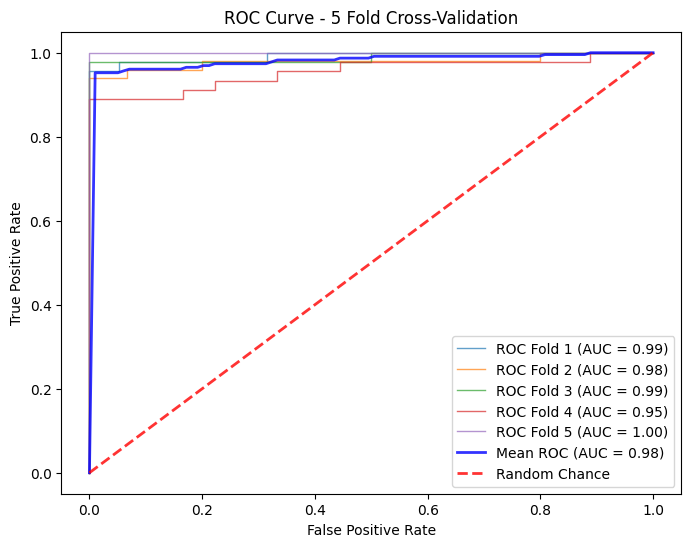

In [116]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [117]:
y.value_counts()

1    230
0     88
Name: Diagnosis, dtype: int64

In [118]:
Thoda rest karlijiye warn rest in peace ho jayegene

SyntaxError: invalid syntax (119544997.py, line 1)

# Dimensionlaity Reduction and Feature Selection Techniques

In [ ]:
# !pip install boruta

In [ ]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])

In [ ]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

In [ ]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [ ]:
df2.info()

In [ ]:
brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
# ruk jaana yaha....

## Shap Value

In [ ]:
# !pip install shap

In [ ]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

In [ ]:
# error

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [ ]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [ ]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

In [ ]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [ ]:
df3.shape

# Applying Fisher Score for feature selection

In [ ]:
# pip install skfeature-chappers

In [ ]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [ ]:
cols

In [ ]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

## Variance Threshold as Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

In [ ]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

## Chi-square Test

In [ ]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

In [ ]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)

In [ ]:
non_cat(Index)

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))